##### Hypotheses

- H1: Weather conditions (rain, snow, storm) are the strongest predictors of
  transit delay, with severe weather producing significantly higher delays.

- H2: Time-based factors (peak hour, time of day, day of week) compound delay
  when combined with adverse weather or nearby events.

- H3: Public events (protests, parades, concerts) increase delay beyond the
  baseline, with larger and more disruptive events having greater impact.

- H4: A machine learning model trained on weather, time, and event features
  can predict delay magnitude and classify commute risk with reasonable accuracy.

**IMPORT**

In [34]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import shap
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, f1_score, classification_report,
                             confusion_matrix, recall_score)
from xgboost import XGBRegressor, XGBClassifier
from imblearn.over_sampling import SMOTE

<h4>SECTION 1: DATA LOADING & DATABASE SETUP</h4>

In [2]:
# ── 1.1  Load CSV ─────────────────────────────────────────────────────────────
CSV_PATH = 'public_transport_delays.csv'

df = pd.read_csv(CSV_PATH)
print("=" * 60)
print("SECTION 1 · DATA LOADING")
print("=" * 60)
print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nColumn Info:")
print(f"{df.dtypes.to_string}")
 
print("\nFirst 5 rows:")
print(f"{df.head().to_string()}")

print("\nLast 5 rows:")
print(f"{df.tail().to_string()}")
 
print("\nDescriptive Statistics (numeric):")
print(f"{df.describe().round(4).to_string()}")

SECTION 1 · DATA LOADING
Shape : 2,000 rows × 24 columns

Column Info:
<bound method Series.to_string of trip_id                        object
date                           object
time                           object
transport_type                 object
route_id                       object
origin_station                 object
destination_station            object
scheduled_departure            object
scheduled_arrival              object
actual_departure_delay_min      int64
actual_arrival_delay_min        int64
weather_condition              object
temperature_C                 float64
humidity_percent                int64
wind_speed_kmh                  int64
precipitation_mm              float64
event_type                     object
event_attendance_est            int64
traffic_congestion_index        int64
holiday                         int64
peak_hour                       int64
weekday                         int64
season                         object
delayed              

In [3]:
# ── 1.2  Store in SQLite ─────────────────────────
conn = sqlite3.connect('transport.db')
df.to_sql('trips', conn, if_exists='replace', index=False)
print("✓ Data loaded into SQLite table 'trips'\n")

✓ Data loaded into SQLite table 'trips'



In [4]:
# ── 1.3  Basic SQL inspection queries ────────────────────────────────────────
def sql(query, label=""):
    """Run a SQL query and pretty-print the result."""
    result = pd.read_sql_query(query, conn)
    if label:
        print(f"── {label} ──")
        print(result.to_string(index=False))
        print()
    return result

# Analyze delay frequency and severity across different transport modes
# to identify which transport type experiences the highest average delays.
sql("""
    SELECT transport_type,
           COUNT(*) AS total_trips,
           ROUND(AVG(actual_arrival_delay_min),2) AS avg_delay_min,
           SUM(delayed) AS delayed_count,
           ROUND(100.0*SUM(delayed)/COUNT(*),1) AS delay_rate_pct
    FROM trips
    GROUP BY transport_type
    ORDER BY avg_delay_min DESC
""", "Delay stats by transport type")

# Compare average delays under different weather conditions
# to evaluate the impact of weather on transport performance.
sql("""
    SELECT weather_condition,
           COUNT(*) AS trips,
           ROUND(AVG(actual_arrival_delay_min),2) AS avg_delay_min
    FROM trips
    GROUP BY weather_condition
    ORDER BY avg_delay_min DESC
""", "Delay stats by weather condition")

# Examine how public events influence transportation delays
# by comparing average delays across different event types.
sql("""
    SELECT COALESCE(event_type,'No Event') AS event,
           COUNT(*) AS trips,
           ROUND(AVG(actual_arrival_delay_min),2) AS avg_delay_min
    FROM trips
    GROUP BY event
    ORDER BY avg_delay_min DESC
""", "Delay stats by event type")

# Investigate seasonal trends in transport delays and congestion levels
# to determine whether certain seasons are associated with worse performance.
sql("""
    SELECT season,
           ROUND(AVG(actual_arrival_delay_min),2) AS avg_delay_min,
           ROUND(AVG(traffic_congestion_index),1) AS avg_congestion
    FROM trips
    GROUP BY season
    ORDER BY avg_delay_min DESC
""", "Delay & congestion by season")

# Compare average delays during peak and off-peak hours
# to assess the effect of rush-hour traffic on transit reliability.
sql("""
    SELECT peak_hour,
           ROUND(AVG(actual_arrival_delay_min),2) AS avg_delay
    FROM trips
    GROUP BY peak_hour
""", "Peak vs off-peak delay")

# Measure the impact of public holidays on transport delays
# by comparing average delays between holiday and non-holiday trips.
sql("""
    SELECT holiday,
           ROUND(AVG(actual_arrival_delay_min),2) AS avg_delay
    FROM trips
    GROUP BY holiday
""", "Holiday impact on delay")

# Identify the routes with the highest average delays
# to highlight potential operational bottlenecks and problem routes.
sql("""
    SELECT route_id,
           ROUND(AVG(actual_arrival_delay_min),2) AS avg_delay
    FROM trips
    GROUP BY route_id
    ORDER BY avg_delay DESC
    LIMIT 10
""", "Top 10 most delayed routes")

── Delay stats by transport type ──
transport_type  total_trips  avg_delay_min  delayed_count  delay_rate_pct
         Train          493          13.55            379            76.9
           Bus          525          13.54            395            75.2
         Metro          491          13.21            350            71.3
          Tram          491          12.95            375            76.4

── Delay stats by weather condition ──
weather_condition  trips  avg_delay_min
             Rain    321          13.62
             Snow    343          13.53
            Clear    343          13.50
            Storm    337          13.29
           Cloudy    325          13.07
              Fog    331          12.88

── Delay stats by event type ──
   event  trips  avg_delay_min
 Protest     86          13.90
  Parade    105          13.62
No Event   1173          13.53
 Concert    203          12.83
  Sports    212          12.82
Festival    221          12.77

── Delay & congestion b

,route_id,avg_delay
0,Route_12,14.29
1,Route_18,14.13
2,Route_15,13.99
3,Route_5,13.87
4,Route_6,13.84
5,Route_7,13.58
6,Route_14,13.50
7,Route_17,13.47
8,Route_20,13.46
9,Route_1,13.43


<h4>SECTION 2: DATA QUALITY CHECK</h4>

In [5]:
print("=" * 60)
print("SECTION 2 · DATA QUALITY")
print("=" * 60)
 
# ── 2.1  Missing values ───────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
quality = quality[quality['missing_count'] > 0]

if quality.empty:
    print("No missing values in numeric/non-event columns")
else:
    print("Columns with missing values:")
    print(quality.to_string())
print()

# fill event_type which has NaN (no event)
df['event_label'] = df['event_type'].fillna('No Event')

SECTION 2 · DATA QUALITY
Columns with missing values:
            missing_count  missing_pct
event_type           1173        58.65



In [6]:
# ── 2.2  Data types & ranges ──────────────────────────────────────────────────

# Review summary statistics to identify unusual values, outliers, and data quality issues
print("── Numeric column ranges ──")

num_cols = [
    'actual_departure_delay_min',
    'actual_arrival_delay_min',
    'temperature_C',
    'humidity_percent',
    'wind_speed_kmh',
    'precipitation_mm',
    'traffic_congestion_index',
    'event_attendance_est'
]

print(df[num_cols].describe().round(2).to_string())
print()

── Numeric column ranges ──
       actual_departure_delay_min  actual_arrival_delay_min  temperature_C  humidity_percent  wind_speed_kmh  precipitation_mm  traffic_congestion_index  event_attendance_est
count                     2000.00                   2000.00        2000.00           2000.00         2000.00           2000.00                   2000.00               2000.00
mean                         8.69                     13.32          15.12             64.71           29.30              9.86                     50.24               6420.25
std                          6.27                      9.29          11.48             20.33           17.26              5.78                     29.23              15198.31
min                         -2.00                     -3.00          -5.00             30.00            0.00              0.00                      0.00                  0.00
25%                          3.00                      5.00           5.10             46.00     

In [7]:
# ── 2.3  Class balance ────────────────────────────────────────────────────────
delayed_rate = df['delayed'].mean()
print(f"── Class balance ──")
print(f"Delayed : {df['delayed'].sum():,} trips ({delayed_rate*100:.1f}%)")
print(f"On-time : {(~df['delayed'].astype(bool)).sum():,} trips ({(1-delayed_rate)*100:.1f}%)")
print("\n⚠ Monitor class imbalance during modeling and consider class_weight or SMOTE if needed")

── Class balance ──
Delayed : 1,499 trips (75.0%)
On-time : 501 trips (25.0%)

⚠ Monitor class imbalance during modeling and consider class_weight or SMOTE if needed


In [8]:
# Check for duplicate trip records that could bias analysis and model training.
dupes = df.duplicated(subset='trip_id').sum()

print(f"Duplicate trip IDs : {dupes}")

Duplicate trip IDs : 0


<h4>SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)</h4>

In [9]:
# ── Parse hour from time column ───────────────────────────────────────────────
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

# ── Plot theme ────────────────────────────────────────────────────────────────
DARK = '#0f1117'
CARD = '#1a1d27'
ACCENT = '#4f8ef7'
ACCENT2 = '#f7c34f'
ACCENT3 = '#f7614f'
ACCENT4 = '#4ff7b8'
TEXT = '#e8eaf0'
SUBTEXT = '#8b90a0'
palette = [ACCENT, ACCENT2, ACCENT3, ACCENT4, '#b44ff7', '#f74fb4']
 
plt.rcParams.update({
    'figure.facecolor' : DARK, 'axes.facecolor' : CARD,
    'axes.edgecolor' : '#2a2d3a', 'axes.labelcolor': TEXT,
    'xtick.color' : SUBTEXT, 'ytick.color' : SUBTEXT,
    'text.color' : TEXT, 'grid.color' : '#2a2d3a',
    'grid.linewidth' : 0.5, 'font.family' : 'DejaVu Sans',
    'axes.titlecolor' : TEXT, 'axes.titlesize' : 11,
    'axes.labelsize' : 9,
})
 
fig = plt.figure(figsize=(18, 22), facecolor=DARK)
fig.suptitle('Public Transport Delay — Exploratory Data Analysis',
             fontsize=18, color=TEXT, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35,
                       left=0.06, right=0.97, top=0.95, bottom=0.04)

In [10]:
# ── Plot 1 · Delay distribution ───────────────────────────────────────────────
# To understand the overall delay pattern, central tendency, and potential outliers
ax1 = fig.add_subplot(gs[0, 0])
vals = df['actual_arrival_delay_min']

ax1.hist(vals, bins=35, color=ACCENT, edgecolor='none', alpha=0.9)
ax1.axvline(vals.mean(), color=ACCENT2, lw=1.5, ls='--', label=f'Mean {vals.mean():.1f} min')
ax1.axvline(vals.median(), color=ACCENT3, lw=1.5, ls='--', label=f'Median {vals.median():.1f} min')
ax1.set_title('Delay Distribution (arrival)')
ax1.set_xlabel('Delay (min)'); ax1.set_ylabel('Count')
ax1.legend(fontsize=8, framealpha=0.2); ax1.grid(axis='y')

In [11]:
# ── Plot 2 · Delayed vs on-time bar chart ─────────────────────────────────────
# Assess class balance for the classification task
ax2 = fig.add_subplot(gs[0, 1])
labels_bar = ['On-Time', 'Delayed']
counts_bar = [df['delayed'].eq(0).sum(), df['delayed'].eq(1).sum()]
pcts = [c / len(df) * 100 for c in counts_bar]

bars_2 = ax2.bar(labels_bar, counts_bar, color=[ACCENT4, ACCENT3],
                 edgecolor='none', width=0.4)
for bar, pct, cnt in zip(bars_2, pcts, counts_bar):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom',
             color=TEXT, fontsize=9)
ax2.set_title('Delayed vs On-Time Trips')
ax2.set_ylabel('Number of Trips')
ax2.set_ylim(0, max(counts_bar) * 1.2)
ax2.grid(axis='y')

In [12]:
# ── Plot 3 · Average delay by weather ─────────────────────────────────────────────
# Examine how weather conditions affect average arrival delays and identify weather-related operational risks
ax3 = fig.add_subplot(gs[0, 2])

# Calculate average arrival delay for each weather condition.
wd = df.groupby('weather_condition')['actual_arrival_delay_min'] \
       .mean() \
       .sort_values()

bars = ax3.barh(wd.index, wd.values, color=palette[:len(wd)], edgecolor='none')
for bar, val in zip(bars, wd.values):
    ax3.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}', va='center', color=TEXT, fontsize=8)
ax3.set_title('Average Delay by Weather Condition')
ax3.set_xlabel('Average Delay (min)'); ax3.grid(axis='x')

In [13]:
# ── Plot 4 · Delay by hour (time series) ──────────────────────────────────────
# Highlight potential rush-hour effects on transportation performance
ax4 = fig.add_subplot(gs[1, :2])

# Compute average delay for each hour of the day
hourly = df.groupby('hour')['actual_arrival_delay_min'].mean()

ax4.fill_between(hourly.index, hourly.values, alpha=0.25, color=ACCENT)
ax4.plot(hourly.index, hourly.values, color=ACCENT, lw=2, marker='o', ms=4)
ax4.axvspan(7, 9, alpha=0.12, color=ACCENT2, label='Morning rush (7–9)')
ax4.axvspan(16, 19, alpha=0.12, color=ACCENT3, label='Evening rush (16–19)')
ax4.set_title('Average Arrival Delay by Hour of Day')
ax4.set_xlabel('Hour'); ax4.set_ylabel('Avg Delay (min)')
ax4.set_xticks(range(0, 24))
ax4.legend(fontsize=8, framealpha=0.2); ax4.grid()

In [14]:
# ── Plot 5 · Delay by transport type (boxplot) ────────────────────────────────
# Evaluate variability and identify high-risk transport types
ax5 = fig.add_subplot(gs[1, 2])
transport_order = (df.groupby('transport_type')['actual_arrival_delay_min']
                   .median().sort_values(ascending=False).index)

bp = ax5.boxplot(
    [df[df['transport_type'] == t]['actual_arrival_delay_min'].values
     for t in transport_order],
    tick_labels=transport_order, patch_artist=True,
    medianprops=dict(color=ACCENT2, lw=2),
    whiskerprops=dict(color=SUBTEXT), capprops=dict(color=SUBTEXT),
    flierprops=dict(marker='.', color=SUBTEXT, alpha=0.4, ms=3))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax5.set_title('Delay by Transport Type')
ax5.set_ylabel('Delay (min)'); ax5.grid(axis='y')

In [15]:
# ── Plot 6 · Average delay by event type ──────────────────────────────────────────
# Determine whether public events contribute to congestion
ax6 = fig.add_subplot(gs[2, 0])

# Calculate average delay for each event category
ed = (df.groupby('event_label')['actual_arrival_delay_min']
      .mean().sort_values(ascending=False))

colors_ev = [ACCENT3 if v == ed.max() else ACCENT for v in ed.values]
bars2 = ax6.bar(ed.index, ed.values, color=colors_ev, edgecolor='none')
for bar, val in zip(bars2, ed.values):
    ax6.text(bar.get_x() + bar.get_width() / 2, val + 0.1,
             f'{val:.1f}', ha='center', va='bottom', color=TEXT, fontsize=7.5)
ax6.set_title('Average Delay by Event Type')
ax6.set_ylabel('Average Delay (min)')
ax6.tick_params(axis='x', labelsize=7.5, rotation=15); ax6.grid(axis='y')

In [16]:
# ── Plot 7 · Average delay by season ──────────────────────────────────────────────
# Identify periods associated with poorer service reliability
ax7 = fig.add_subplot(gs[2, 1])

# Calculate average delay by season
sd = (df.groupby('season')['actual_arrival_delay_min']
      .mean().sort_values(ascending=False))

colors_s = [ACCENT2 if v == sd.max() else ACCENT4 for v in sd.values]
bars3 = ax7.bar(sd.index, sd.values, color=colors_s, edgecolor='none', width=0.5)
for bar, val in zip(bars3, sd.values):
    ax7.text(bar.get_x() + bar.get_width() / 2, val + 0.05,
             f'{val:.1f}', ha='center', va='bottom', color=TEXT, fontsize=8)
ax7.set_title('Average Delay by Season')
ax7.set_ylabel('Average Delay (min)'); ax7.set_ylim(0, 17); ax7.grid(axis='y')

In [17]:
# ── Plot 8 · Correlation heatmap ──────────────────────────────────────────────
# Identify potentially informative features
ax8 = fig.add_subplot(gs[2, 2])
heat_cols = ['actual_arrival_delay_min', 'temperature_C', 'humidity_percent',
             'wind_speed_kmh', 'precipitation_mm', 'traffic_congestion_index',
             'event_attendance_est', 'peak_hour', 'holiday']
heat_labels = ['Delay', 'Temp', 'Humidity', 'Wind', 'Rain',
               'Traffic', 'Attendance', 'Peak', 'Holiday']

# Compute pairwise feature correlations
corr = df[heat_cols].corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, ax=ax8, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 6.5},
            xticklabels=heat_labels, yticklabels=heat_labels,
            linewidths=0.3, linecolor='#1a1d27',
            cbar_kws={'shrink': 0.8})
ax8.set_title('Feature Correlation Matrix')
ax8.tick_params(labelsize=7, rotation=30)

In [18]:
# ── Plot 9 · Holiday & peak hour comparison ───────────────────────────────────
# Evaluate the influence of demand-related factors on delays
ax9 = fig.add_subplot(gs[3, 0])
groups = {
    'Weekday\n(No Holiday)' : df[df['holiday'] == 0]['actual_arrival_delay_min'],
    'Holiday'               : df[df['holiday'] == 1]['actual_arrival_delay_min'],
    'Peak Hour'             : df[df['peak_hour'] == 1]['actual_arrival_delay_min'],
    'Off-Peak'              : df[df['peak_hour'] == 0]['actual_arrival_delay_min'],
}

# Calculate average delay for each group
means = {k: v.mean() for k, v in groups.items()}

bars4 = ax9.bar(means.keys(), means.values(),
                color=[ACCENT, ACCENT2, ACCENT3, ACCENT4],
                edgecolor='none', width=0.5)
for bar, val in zip(bars4, means.values()):
    ax9.text(bar.get_x() + bar.get_width() / 2, val + 0.05,
             f'{val:.1f}', ha='center', va='bottom', color=TEXT, fontsize=8)
ax9.set_title('Delay: Holiday vs Peak Hour')
ax9.set_ylabel('Average Delay (min)')
ax9.set_ylim(0, 17); ax9.tick_params(axis='x', labelsize=7.5); ax9.grid(axis='y')

In [19]:
# ── Plot 10 · Delay by day of week ────────────────────────────────────────────
# Identify recurring weekly trends in transportation performance
ax10 = fig.add_subplot(gs[3, 1])

# Convert weekday numbers into readable labels
day_names = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu',
             4: 'Fri', 5: 'Sat', 6: 'Sun'}

# Calculate average delay for each day of the week
wd2 = df.groupby('weekday')['actual_arrival_delay_min'].mean()
wd2.index = [day_names[i] for i in wd2.index]
x = range(len(wd2))

ax10.plot(x, wd2.values, color=ACCENT4, lw=2, marker='D',
          ms=6, markerfacecolor=ACCENT2)
ax10.fill_between(x, wd2.values, alpha=0.15, color=ACCENT4)
ax10.set_title('Average Delay by Day of Week')
ax10.set_ylabel('Average Delay (min)')
ax10.set_xticks(x); ax10.set_xticklabels(wd2.index); ax10.grid()

SECTION 3 · EDA


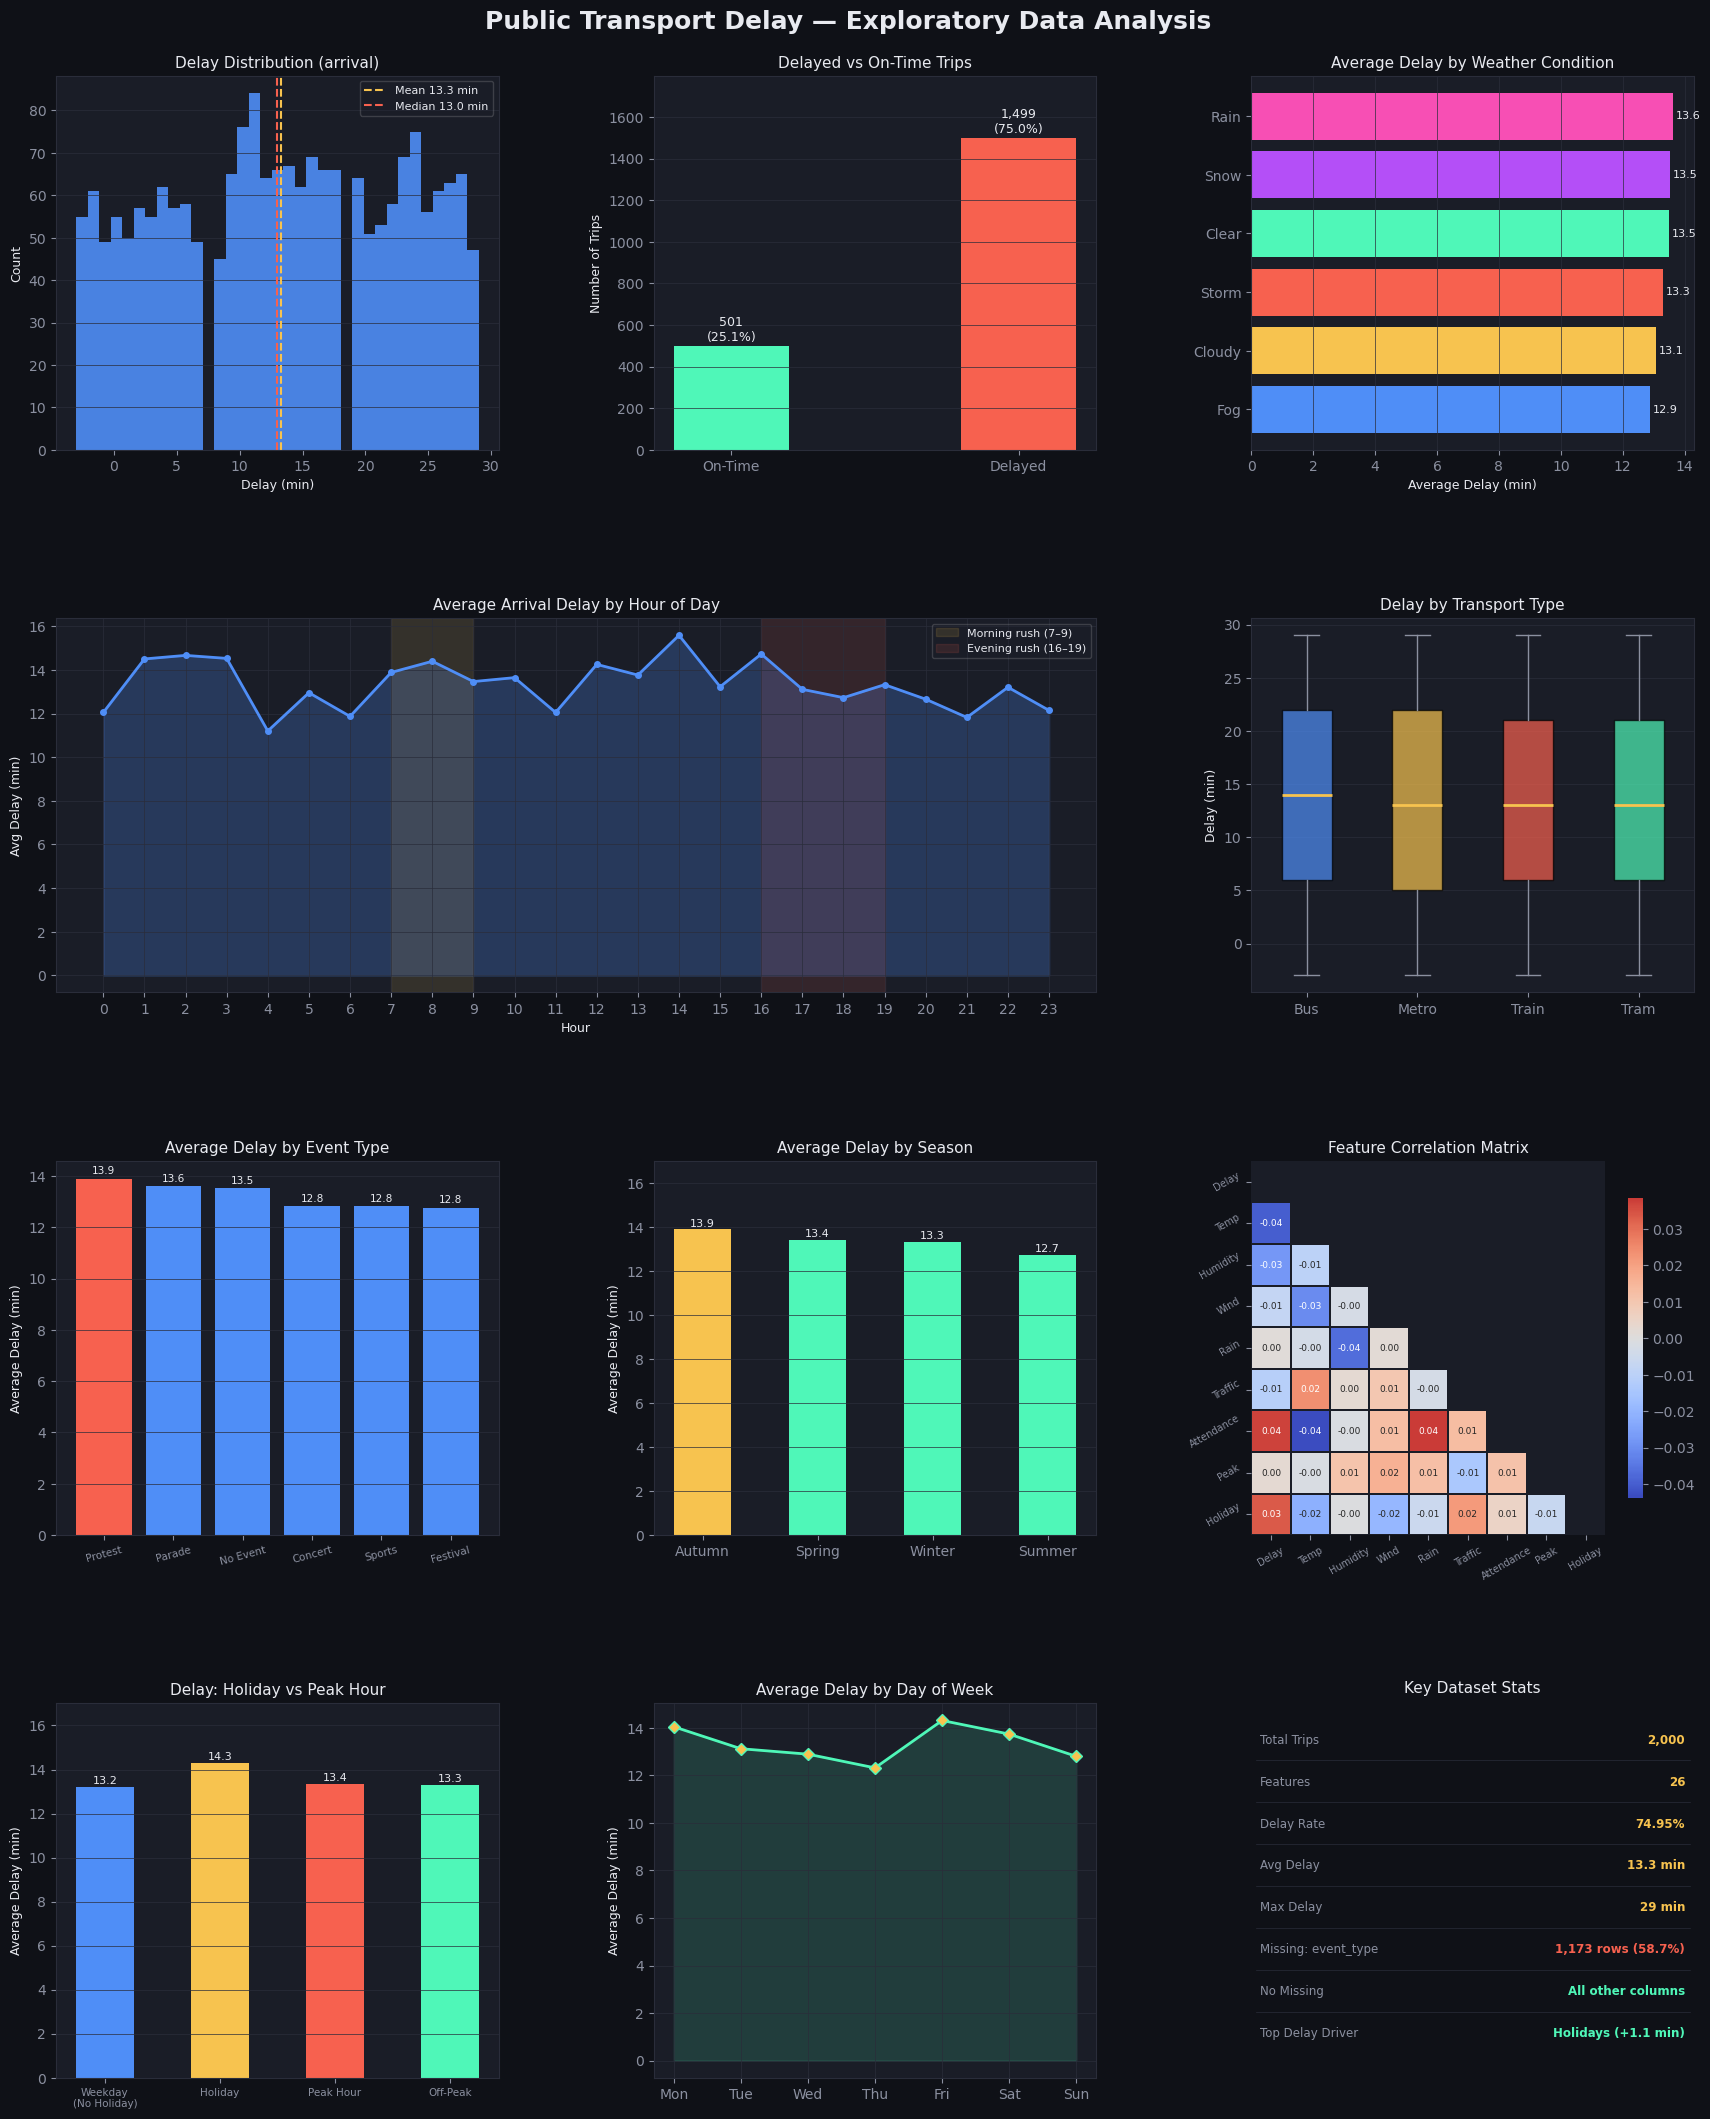

In [20]:
# ── Plot 11 · Key stats summary panel ────────────────────────────────────────
ax11 = fig.add_subplot(gs[3, 2])
ax11.set_facecolor(CARD); ax11.axis('off')
ax11.set_title('Key Dataset Stats', pad=8)
missing_event = df['event_type'].isnull().sum()
missing_event_pct = missing_event / len(df) * 100
holiday_delay = df[df['holiday'] == 1]['actual_arrival_delay_min'].mean()
no_holiday_delay = df[df['holiday'] == 0]['actual_arrival_delay_min'].mean()
holiday_diff = holiday_delay - no_holiday_delay

stats = [
    ('Total Trips',         f"{len(df):,}"),
    ('Features',            f"{df.shape[1]}"),
    ('Delay Rate',          f"{df['delayed'].mean()*100:.2f}%"),
    ('Avg Delay',           f"{df['actual_arrival_delay_min'].mean():.1f} min"),
    ('Max Delay',           f"{df['actual_arrival_delay_min'].max():.0f} min"),
    ('Missing: event_type', f"{missing_event:,} rows ({missing_event_pct:.1f}%)"),
    ('No Missing',          'All other columns'),
    ('Top Delay Driver',    f"Holidays (+{holiday_diff:.1f} min)"),
]

stat_colors = [ACCENT2, ACCENT2, ACCENT2, ACCENT2,
               ACCENT2, ACCENT3, ACCENT4, ACCENT4]

for i, (label, val) in enumerate(stats):
    y = 0.92 - i * 0.112
    ax11.text(0.02, y, label, transform=ax11.transAxes,
              color=SUBTEXT, fontsize=8.5, va='top')
    ax11.text(0.98, y, val,   transform=ax11.transAxes,
              color=stat_colors[i], fontsize=8.5, va='top',
              ha='right', fontweight='bold')
    if i < len(stats) - 1:
        line = Line2D([0.01, 0.99], [y - 0.072, y - 0.072],
                      transform=ax11.transAxes, color='#2a2d3a', lw=0.5)
        ax11.add_line(line)


print("=" * 60)
print("SECTION 3 · EDA")
print("=" * 60)

plt.tight_layout()
plt.show()

**SUMMARY OF EDA FINDINGS**

- Class imbalance : 74.95% delayed — use class_weight='balanced' or SMOTE for classification models
- Weather impact : Rain > Snow > Clear, but differences are relatively small (~1 min) 
- Event impact : Protests & Parades are associated with the highest average delays — encode severity 
- Season impact : Autumn has the highest average delay, while Summer has the lowest — encode ordinally 
- Holiday impact : Strongest single predictor → +1.1 min vs non-holiday 
- Peak hour : Minimal raw impact — but useful in interaction features 
- Hourly pattern : Clear time-of-day variation — extract 'hour' as feature 
- Correlations : Most individual features exhibit weak linear correlations with delay
- Missing data : event_type contains NaN → encoded as 'No Event' before modeling

<h4>SECTION 4: FEATURE ENGINEERING</h4>

In [22]:
print("=" * 60)
print("SECTION 4 · FEATURE ENGINEERING")
print("=" * 60)
print(f"Original shape: {df.shape}")

SECTION 4 · FEATURE ENGINEERING
Original shape: (2000, 26)


In [23]:
# ── 4.1  Time Features ────────────────────────────────────────────────────────
print("── 4.1 Time Features ──")
 
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
 
df['is_morning_rush'] = df['hour'].between(7, 9).astype(int)
df['is_evening_rush'] = df['hour'].between(16, 19).astype(int)

# Categorize each trip into a broader time-of-day segment
def time_of_day(h):
    if 0 <= h < 6: return 0         # night
    elif 6 <= h < 12: return 1      # morning
    elif 12 <= h < 17: return 2     # afternoon
    else: return 3                  # evening
 
df['time_of_day'] = df['hour'].apply(time_of_day)

# Calculate scheduled trip duration as a proxy for route complexity
dep = pd.to_datetime(df['scheduled_departure'], format='%H:%M:%S')
arr = pd.to_datetime(df['scheduled_arrival'],format='%H:%M:%S')
df['scheduled_duration_min'] = (arr - dep).dt.seconds / 60
 
# Cyclical encoding of hour 
# Numerically 23:00 and 00:00 look far apart but they are actually close in time
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

print("  ✓ hour, month, is_morning_rush, is_evening_rush, time_of_day, scheduled_duration_min, hour_sin, hour_cos")


# ── 4.2  Weather Condition (one-hot encoding) ─────────────────────────────────
print("\n── 4.2 Weather Condition ──")

weather_dummies = pd.get_dummies(df['weather_condition'], prefix='weather', drop_first=True)
df = pd.concat([df, weather_dummies], axis=1)
 
# Create a binary indicator for adverse weather conditions
df['is_bad_weather'] = df['weather_condition'].isin(['Rain', 'Snow', 'Storm']).astype(int)
 
print(f"  One-hot columns : {list(weather_dummies.columns)}")
print("  ✓ weather dummies, is_bad_weather")


# ── 4.3  Event Severity (ordinal encoding) ───────────────────────────────────
print("\n── 4.3 Event Severity ──")

# Assign severity scores to event types based on EDA findings
# protests and parades were associated with the highest delays
event_severity = {
    'No Event' : 0,
    'Concert'  : 1,
    'Festival' : 2,
    'Sports'   : 3,
    'Parade'   : 4,
    'Protest'  : 5,
}

# Replace missing event values with 'No Event'
df['event_label'] = df['event_type'].fillna('No Event')

# Convert event categories into ordinal severity scores
df['event_severity'] = df['event_label'].map(event_severity)

# Create a binary flag indicating whether an event is present
df['has_event'] = (df['event_severity'] > 0).astype(int)
 
print(f"  Mapping : {event_severity}")
print("  ✓ event_severity, has_event")


# ── 4.4  Season (one-hot encoding) ───────────────────────────────────
print("\n── 4.4 Season ──")
 
# Seasons have no natural numeric order and should be treated as independent categories
season_dummies = pd.get_dummies(df['season'], prefix='season', drop_first=True)
df = pd.concat([df, season_dummies], axis=1)
 
print(f"  One-hot columns : {list(season_dummies.columns)}")
print("  ✓ season dummies")


# ── 4.5  Label Encoding — Categorical Columns ──────────────────────────
print("\n── 4.5 Label Encoding — Categorical Columns ──")
 
# Encode high-cardinality categorical variables into numeric labels so they can be used by machine learning algorithms
le = LabelEncoder()

for col in ['transport_type', 'route_id', 'origin_station', 'destination_station']:
    df[f'{col}_enc'] = le.fit_transform(df[col])
    print(f"  ✓ {col}_enc  ({df[col].nunique()} unique values)")


# ── 4.6  Interaction Features ────────────────────────────────────────────
print("\n── 4.6 Interaction Features ──")
 
# Bad conditions during rush hour = compounded delay
df['bad_weather_x_peak'] = df['is_bad_weather'] * df['peak_hour']
 
# Large and disruptive events cause more disruption
df['event_x_attendance'] = df['event_severity'] * np.log1p(df['event_attendance_est'])
 
# Traffic congestion have stronger effects during peak periods
df['congestion_x_peak'] = df['traffic_congestion_index'] * df['peak_hour']
 
# Certain hours hit harder by weather
df['hour_x_bad_weather'] = df['hour'] * df['is_bad_weather']
 
# Holiday effects may be amplified on weekends
df['is_weekend'] = (df['weekday'] >= 5).astype(int)
df['holiday_x_weekend'] = df['holiday'] * df['is_weekend']
 
print("  ✓ bad_weather_x_peak")
print("  ✓ event_x_attendance")
print("  ✓ congestion_x_peak")
print("  ✓ hour_x_bad_weather")
print("  ✓ holiday_x_weekend, is_weekend")


# ── 4.7  Train / Val / Test Split ────────────────────────────────────────
print("\n── 4.7 Train / Val / Test Split ──")
 
df = df.sort_values(['date', 'time']).reset_index(drop=True)
 
# Identify feature columns (exclude raw/target columns)
DROP_COLS = [
    'trip_id', 'date', 'time', 'scheduled_departure', 'scheduled_arrival',
    'weather_condition', 'event_type', 'event_label', 'season',
    'transport_type', 'route_id', 'origin_station', 'destination_station',
]
TARGET_REG = 'actual_arrival_delay_min'
TARGET_CLF = 'delayed'
 
# Temporary feature set
pre_split_features = [c for c in df.columns if c not in DROP_COLS +
                      [TARGET_REG, 'actual_departure_delay_min', TARGET_CLF]]

# Separate features from target variables
X = df[pre_split_features]
y_reg = df[TARGET_REG]
y_clf = df[TARGET_CLF]
 
# 70% training / 30% temporary
X_train, X_temp, y_reg_train, y_reg_temp, y_clf_train, y_clf_temp = train_test_split(
    X, y_reg, y_clf, test_size=0.30, random_state=42, stratify=y_clf
)
 
# 15% validation / 15% test (split the remaining data equally)
X_val, X_test, y_reg_val, y_reg_test, y_clf_val, y_clf_test = train_test_split(
    X_temp, y_reg_temp, y_clf_temp,
    test_size=0.50, random_state=42, stratify=y_clf_temp
)
 
print(f"  Train : {len(X_train):>5,} rows   ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Val   : {len(X_val):>5,} rows   ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Test  : {len(X_test):>5,} rows   ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n  Delayed rate — Train: {y_clf_train.mean()*100:.1f}% | "
      f"Val: {y_clf_val.mean()*100:.1f}% | Test: {y_clf_test.mean()*100:.1f}%")
print("  ✓ Stratification maintained across all splits")

# Store split indices for final rebuild
train_idx = X_train.index
val_idx = X_val.index
test_idx = X_test.index


# ── 4.8  Final Feature Set ───────────────────────────────────────────────
print("\n── 4.8 Final Feature Set ──")
 
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS +
                [TARGET_REG, 'actual_departure_delay_min', TARGET_CLF]]
 
print(f"\n  Total features : {len(FEATURE_COLS)}")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"    {i:02d}. {f}")
 
# Rebuild splits with final feature set
X_train = df.loc[train_idx, FEATURE_COLS]
X_val = df.loc[val_idx, FEATURE_COLS]
X_test = df.loc[test_idx, FEATURE_COLS]


OUTPUT_PATH = 'transport_features.csv'
df.to_csv(OUTPUT_PATH, index=False)
print(f"\n  ✓ Processed dataset saved → {OUTPUT_PATH}")
print(f"    Final shape: {df.shape}")

── 4.1 Time Features ──
  ✓ hour, month, is_morning_rush, is_evening_rush, time_of_day, scheduled_duration_min, hour_sin, hour_cos

── 4.2 Weather Condition ──
  One-hot columns : ['weather_Cloudy', 'weather_Fog', 'weather_Rain', 'weather_Snow', 'weather_Storm']
  ✓ weather dummies, is_bad_weather

── 4.3 Event Severity ──
  Mapping : {'No Event': 0, 'Concert': 1, 'Festival': 2, 'Sports': 3, 'Parade': 4, 'Protest': 5}
  ✓ event_severity, has_event

── 4.4 Season ──
  One-hot columns : ['season_Spring', 'season_Summer', 'season_Winter']
  ✓ season dummies

── 4.5 Label Encoding — Categorical Columns ──
  ✓ transport_type_enc  (4 unique values)
  ✓ route_id_enc  (20 unique values)
  ✓ origin_station_enc  (50 unique values)
  ✓ destination_station_enc  (50 unique values)

── 4.6 Interaction Features ──
  ✓ bad_weather_x_peak
  ✓ event_x_attendance
  ✓ congestion_x_peak
  ✓ hour_x_bad_weather
  ✓ holiday_x_weekend, is_weekend

── 4.7 Train / Val / Test Split ──
  Train : 1,400 rows   (70%)

**Feature Visualizations**

Feature visualisations


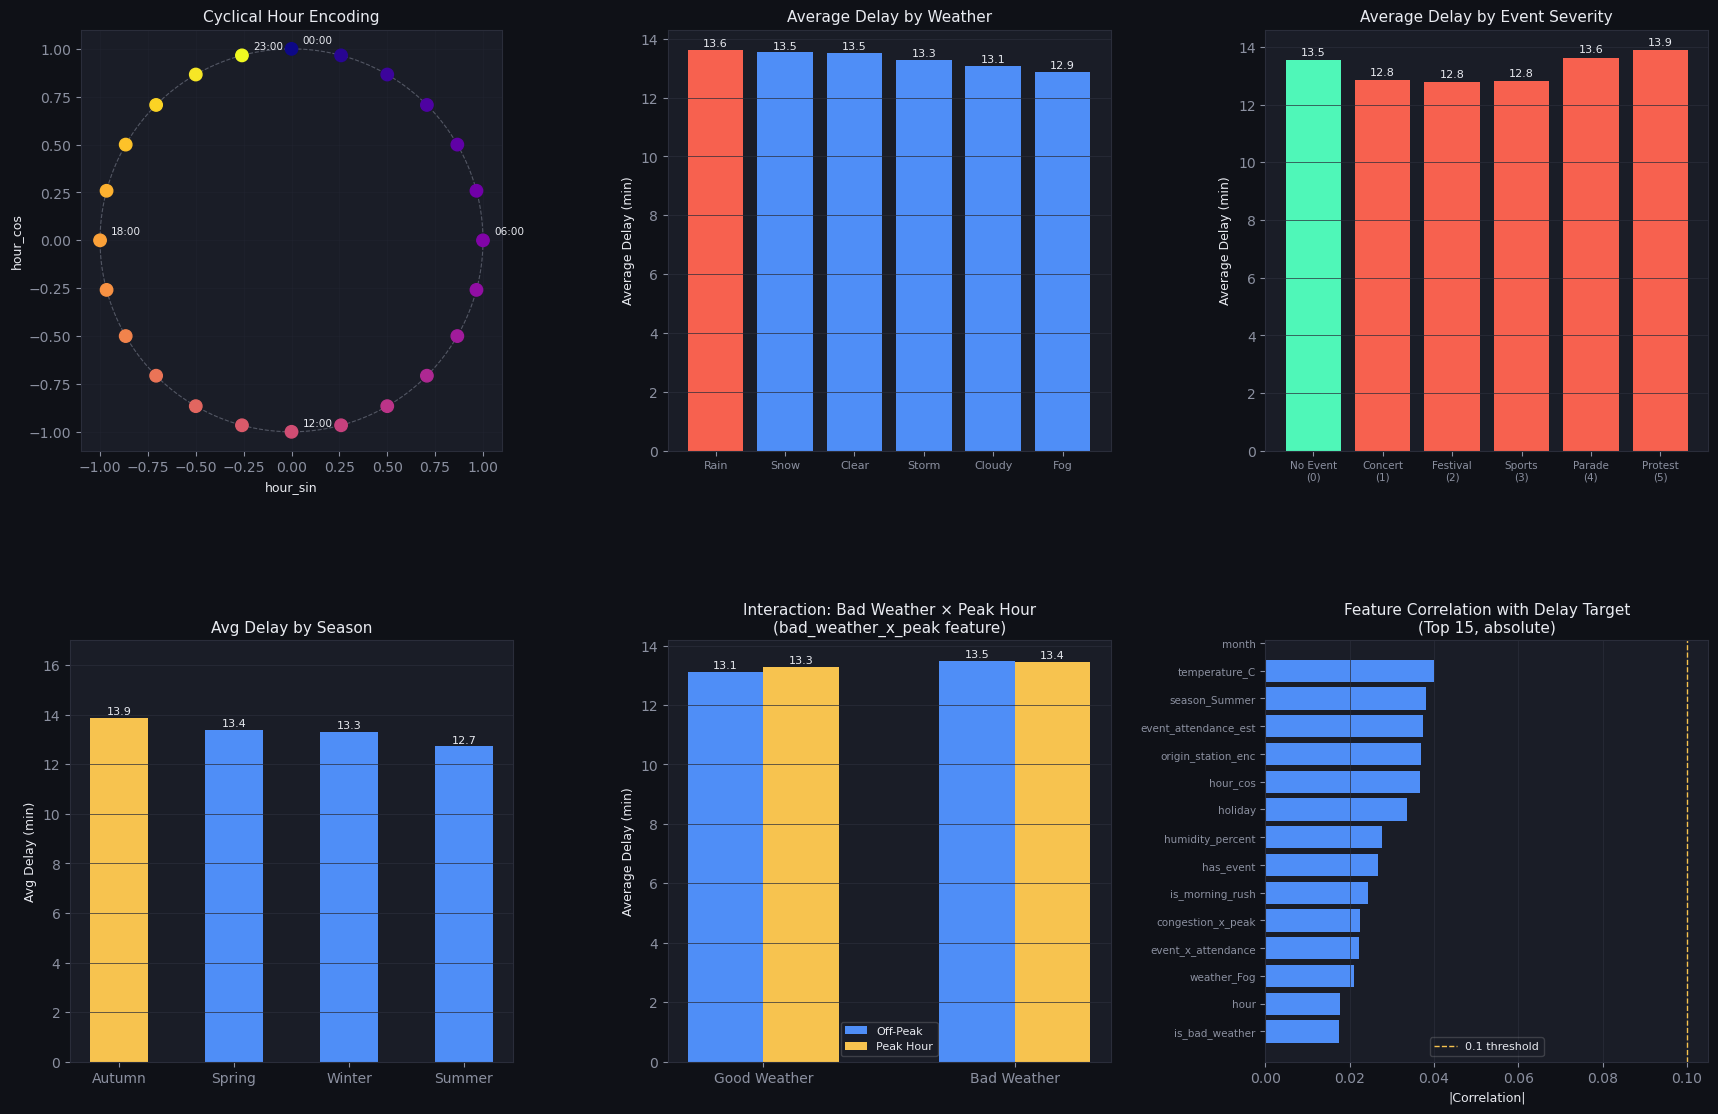

In [24]:
print("Feature visualisations")
 
DARK='#0f1117'; CARD='#1a1d27'; ACCENT='#4f8ef7'; ACCENT2='#f7c34f'
ACCENT3='#f7614f'; ACCENT4='#4ff7b8'; TEXT='#e8eaf0'; SUBTEXT='#8b90a0'
palette=[ACCENT, ACCENT2, ACCENT3, ACCENT4, '#b44ff7', '#f74fb4']
 
plt.rcParams.update({
    'figure.facecolor':DARK, 'axes.facecolor':CARD, 'axes.edgecolor':'#2a2d3a',
    'axes.labelcolor':TEXT, 'xtick.color':SUBTEXT, 'ytick.color':SUBTEXT,
    'text.color':TEXT, 'grid.color':'#2a2d3a', 'grid.linewidth':0.5,
    'font.family':'DejaVu Sans', 'axes.titlesize':11, 'axes.labelsize':9,
})
 
fig = plt.figure(figsize=(18, 12), facecolor=DARK)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
                       left=0.06, right=0.97, top=0.93, bottom=0.07)


# ── Plot 1 · Cyclical hour encoding ──────────────────────────────────────────
# Confirm late-night and early-morning hours are encoded as close together, unlike raw hour values
ax1 = fig.add_subplot(gs[0, 0])
hours = np.arange(24)
sc = ax1.scatter(np.sin(2 * np.pi * hours / 24),
                 np.cos(2 * np.pi * hours / 24),
                 c=hours, cmap='plasma', s=80, zorder=3)
for h in [0, 6, 12, 18, 23]:
    x = np.sin(2 * np.pi * h / 24)
    y = np.cos(2 * np.pi * h / 24)
    ax1.annotate(f'{h:02d}:00', (x, y), textcoords='offset points',
                 xytext=(8, 4), color=TEXT, fontsize=7.5)
theta = np.linspace(0, 2 * np.pi, 200)
ax1.plot(np.sin(theta), np.cos(theta), color=SUBTEXT, lw=0.8, ls='--', alpha=0.5)
ax1.set_title('Cyclical Hour Encoding')
ax1.set_xlabel('hour_sin'); ax1.set_ylabel('hour_cos')
ax1.set_aspect('equal'); ax1.grid(alpha=0.3)
 

# ── Plot 2 · Average delay by weather ─────────────────────────────────────────
# Justify one-hot encoding over ordinal since no clear severity order exists
ax2 = fig.add_subplot(gs[0, 1])
w_delay = df.groupby('weather_condition')['actual_arrival_delay_min'].mean().sort_values(ascending=False)
colors_wd = [ACCENT3 if v == w_delay.max() else ACCENT for v in w_delay.values]
bars2 = ax2.bar(w_delay.index, w_delay.values, color=colors_wd, edgecolor='none')
for bar, val in zip(bars2, w_delay.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f'{val:.1f}', ha='center', va='bottom', color=TEXT, fontsize=8)
ax2.set_title('Average Delay by Weather')
ax2.set_ylabel('Average Delay (min)'); ax2.grid(axis='y')
ax2.tick_params(axis='x', labelsize=8)
 

# ── Plot 3 · Event severity vs average delay ──────────────────────────────────
# Confirm the ordinal event severity ranking (0–5) is data-driven
ax3 = fig.add_subplot(gs[0, 2])
ev_delay = df.groupby('event_severity')['actual_arrival_delay_min'].mean()
labels_e = ['No Event\n(0)', 'Concert\n(1)', 'Festival\n(2)',
            'Sports\n(3)', 'Parade\n(4)', 'Protest\n(5)']
bars3 = ax3.bar(labels_e[:len(ev_delay)], ev_delay.values,
                color=[ACCENT4 if i == 0 else ACCENT3 for i in ev_delay.index],
                edgecolor='none')
for bar, val in zip(bars3, ev_delay.values):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.1,
             f'{val:.1f}', ha='center', va='bottom', color=TEXT, fontsize=8)
ax3.set_title('Average Delay by Event Severity')
ax3.set_ylabel('Average Delay (min)'); ax3.grid(axis='y')
ax3.tick_params(axis='x', labelsize=7.5)
 
 
# ── Plot 4 · Season average delay ─────────────────────────────────────────────
# Shows season has no meaningful numeric order (Autumn worst, Summer best are not adjacent)
ax4 = fig.add_subplot(gs[1, 0])
s_delay = df.groupby('season')['actual_arrival_delay_min'].mean().sort_values(ascending=False)
colors_s = [ACCENT2 if v == s_delay.max() else ACCENT for v in s_delay.values]
bars4 = ax4.bar(s_delay.index, s_delay.values, color=colors_s, edgecolor='none', width=0.5)
for bar, val in zip(bars4, s_delay.values):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f'{val:.1f}', ha='center', va='bottom', color=TEXT, fontsize=8)
ax4.set_title('Avg Delay by Season')
ax4.set_ylabel('Avg Delay (min)'); ax4.set_ylim(0, 17); ax4.grid(axis='y')
 

# ── Plot 5 · Interaction features — averge delay by bad_weather × peak hour ────
ax5 = fig.add_subplot(gs[1, 1])
interact = df.groupby(['is_bad_weather', 'peak_hour'])['actual_arrival_delay_min'].mean().unstack()
interact.index = ['Good Weather', 'Bad Weather']
interact.columns = ['Off-Peak', 'Peak Hour']
x = np.arange(len(interact.index))
w = 0.3
bars5a = ax5.bar(x - w/2, interact['Off-Peak'], width=w, color=ACCENT, edgecolor='none', label='Off-Peak')
bars5b = ax5.bar(x + w/2, interact['Peak Hour'], width=w, color=ACCENT2, edgecolor='none', label='Peak Hour')
for bar in list(bars5a) + list(bars5b):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{bar.get_height():.1f}', ha='center', va='bottom', color=TEXT, fontsize=8)
ax5.set_title('Interaction: Bad Weather × Peak Hour\n(bad_weather_x_peak feature)')
ax5.set_ylabel('Average Delay (min)')
ax5.set_xticks(x); ax5.set_xticklabels(interact.index)
ax5.legend(fontsize=8, framealpha=0.2); ax5.grid(axis='y')
 
# ── Plot 6 · Feature correlation with target ──────────────────────────────────
# Ranks the top 15 engineered features by absolute correlation with the delay target
ax6 = fig.add_subplot(gs[1, 2])
corr_target = df[FEATURE_COLS + [TARGET_REG]].corr()[TARGET_REG].drop(TARGET_REG)
corr_target = corr_target.abs().sort_values(ascending=True).tail(15)
colors_c = [ACCENT3 if v > 0.1 else ACCENT for v in corr_target.values]
ax6.barh(corr_target.index, corr_target.values, color=colors_c, edgecolor='none')
ax6.axvline(0.1, color=ACCENT2, lw=1, ls='--', label='0.1 threshold')
ax6.set_title('Feature Correlation with Delay Target\n(Top 15, absolute)')
ax6.set_xlabel('|Correlation|')
ax6.legend(fontsize=8, framealpha=0.2); ax6.grid(axis='x')
ax6.tick_params(axis='y', labelsize=7.5)
 
plt.tight_layout()
plt.show()

**OBSERVATIONS**

Plot 3: Event Severity
- The ordinal ranking assigns higher numbers to events expected to cause more delay. However, the data shows Concert, Festival, and Sports all producing identical average delays (12.8 min), meaning the model will treat levels 1, 2, and 3 as meaningfully different when they are not. Only Parade and Protest stand out. The ranking is kept because the top two levels are genuinely higher, but it is not a perfectly clean ordinal scale.

Plot 5: Interaction Feature
- The gap between Off-Peak and Peak Hour is 0.2 min for good weather and actually reverses (−0.1 min) for bad weather. This means bad weather and peak hour do not meaningfully compound each other in this dataset. The feature is kept for modeling since tree-based models may still find signal in combinations, but are not expecting it to be a top contributor.

Plot 6: Feature Correlation
- Linear correlation measures how much a single feature moves in step with the target. All features scoring below 0.1 means no single feature predicts delay on its own. Delays are caused by multiple conditions occurring together (e.g. rush hour + rain + a nearby event), which linear correlation cannot capture. Tree-based models like XGBoost and Random Forest are designed specifically to detect these kinds of combined effects.

<h4>SECTION 5: MACHINE LEARNING MODELING</h4>

In [36]:
# ── 5.1  Load & Rebuild Splits ─────────────────────────────────────────────────────────────
print("=" * 60)
print("SECTION 5 · MACHINE LEARNING MODELING")
print("=" * 60)

df_features = pd.read_csv('transport_features.csv')
 
DROP_COLS = [
    'trip_id', 'date', 'time', 'scheduled_departure', 'scheduled_arrival',
    'weather_condition', 'event_type', 'event_label', 'season',
    'transport_type', 'route_id', 'origin_station', 'destination_station',
]
TARGET_REG = 'actual_arrival_delay_min'
TARGET_CLF = 'delayed'
 
FEATURE_COLS = [c for c in df_features.columns if c not in DROP_COLS +
                [TARGET_REG, 'actual_departure_delay_min', TARGET_CLF]]
 
# Separate predictors from regression and classification targets
X = df_features[FEATURE_COLS]
y_reg = df_features[TARGET_REG]
y_clf = df_features[TARGET_CLF]

# Use a random stratified split to preserve the delayed/on-time distribution 
# across train, validation, and test datasets
# Note: A temporal split would better reflect a real forecasting environment, 
# but a random stratified split is applied for simplicity
X_train, X_temp, y_reg_train, y_reg_temp, y_clf_train, y_clf_temp = train_test_split(
    X, y_reg, y_clf, test_size=0.30, random_state=42, stratify=y_clf)

X_val, X_test, y_reg_val, y_reg_test, y_clf_val, y_clf_test = train_test_split(
    X_temp, y_reg_temp, y_clf_temp, test_size=0.50, random_state=42, stratify=y_clf_temp)

print(f"Features : {len(FEATURE_COLS)}")
print(f"Train    : {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}\n")
 
risk_labels = ['Low', 'Medium', 'High']

SECTION 5 · MACHINE LEARNING MODELING
Features : 38
Train    : 1,400 | Val: 300 | Test: 300



In [27]:
# =============================================================================
# 5.1  Risk Label Strategies 
# =============================================================================
print("── 5.1 Risk Label Strategies ──")

# Strategy A - Define delay risk using fixed business thresholds
# Low Risk    : delay < 10 minutes
# Medium Risk : 10–19 minutes
# High Risk   : 20+ minutes
def assign_risk_fixed(d):
    return 0 if d < 10 else (1 if d < 20 else 2)
 

# Strategy B — Create balanced risk classes using training-set quantiles
# Reduce class imbalance by assigning approximately one-third of observations to each risk category
q1 = y_reg_train.quantile(1/3)
q2 = y_reg_train.quantile(2/3)
 
def assign_risk_quantile(d):
    return 0 if d < q1 else (1 if d < q2 else 2)


# Generate classification labels using both risk-labeling strategies
y_risk_train_fixed = y_reg_train.apply(assign_risk_fixed)
y_risk_test_fixed = y_reg_test.apply(assign_risk_fixed)

y_risk_train_q = y_reg_train.apply(assign_risk_quantile)
y_risk_test_q = y_reg_test.apply(assign_risk_quantile)
 
print(f"  Fixed bins : Low<10  | Medium 10–19  | High≥20")
print(f"  Quantile bins: Low<{q1:.0f}  | Medium {q1:.0f}–{q2:.0f}  | High≥{q2:.0f}")
print(f"\n  Train dist (fixed)   : {y_risk_train_fixed.value_counts().sort_index().to_dict()}")
print(f"  Train dist (quantile): {y_risk_train_q.value_counts().sort_index().to_dict()}")
 
# Apply SMOTE to balance minority classes in the training data
smote = SMOTE(random_state=42)

# Oversample the fixed-bin training dataset
X_sm_fixed, y_sm_fixed = smote.fit_resample(X_train, y_risk_train_fixed)

# Oversample the quantile-bin training dataset
X_sm_q, y_sm_q = smote.fit_resample(X_train, y_risk_train_q)

print(f"\n  After SMOTE (fixed)   : {pd.Series(y_sm_fixed).value_counts().sort_index().to_dict()}")
print(f"  After SMOTE (quantile): {pd.Series(y_sm_q).value_counts().sort_index().to_dict()}")

── 5.1 Risk Label Strategies ──
  Fixed bins : Low<10  | Medium 10–19  | High≥20
  Quantile bins: Low<9  | Medium 9–18  | High≥18

  Train dist (fixed)   : {0: 503, 1: 491, 2: 406}
  Train dist (quantile): {0: 457, 1: 443, 2: 500}

  After SMOTE (fixed)   : {0: 503, 1: 503, 2: 503}
  After SMOTE (quantile): {0: 500, 1: 500, 2: 500}


In [30]:
# =============================================================================
# 5.2  REGRESSION — Linear Regression (baseline) + Random Forest + XGBoost
# =============================================================================
# Linear Regression → interpretable linear baseline
# Random Forest     → bagging ensemble (non-linear, robust to noise)
# XGBoost           → boosting ensemble (sequential error correction)

print("── 5.2 REGRESSION — Predict Delay (minutes) ──")
 
reg_models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'           : XGBRegressor(n_estimators=100, learning_rate=0.1,
                                       random_state=42, verbosity=0),
}
 
reg_results = {}
baseline_rmse = np.sqrt(((y_reg_test - y_reg_train.mean()) ** 2).mean())
 
print(f"\n  Mean-prediction baseline RMSE : {baseline_rmse:.4f} min")
 
for name, model in reg_models.items():
    model.fit(X_train, y_reg_train)      # Fit the model using training data
    preds = model.predict(X_test)        # Generate delay predictions for unseen trips
    
    # Evaluate prediction accuracy using multiple regression metrics
    rmse = np.sqrt(mean_squared_error(y_reg_test, preds))   
    mae = mean_absolute_error(y_reg_test, preds)
    r2 = r2_score(y_reg_test, preds)
    
    # Estimate model stability using 5-fold cross-validation
    cv = cross_val_score(model, X_train, y_reg_train,
                         cv=5, scoring='neg_root_mean_squared_error')
    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2,
                         'CV RMSE': -cv.mean(), 'model': model, 'preds': preds}
    print(f"  {name}")
    print(f"    RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  CV RMSE={-cv.mean():.4f}±{cv.std():.4f}")

# Select the model with the lowest test-set RMSE
best_reg_name = min(reg_results, key=lambda k: reg_results[k]['RMSE'])
best_reg = reg_results[best_reg_name]['model']
print(f"\n  ✓ Best baseline : {best_reg_name} (RMSE={reg_results[best_reg_name]['RMSE']:.4f})")
 

# ── Hyperparameter tuning — Random Forest & XGBoost ──────────────────────────
print(f"\n── GridSearchCV Tuning (cv=5) ──")
 
tuning_configs = {
    'Random Forest': (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [None, 10, 20],
         'min_samples_split': [2, 5]}
    ),
    'XGBoost': (
        XGBRegressor(random_state=42, verbosity=0),
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 6]}
    ),
}
 
tuned_reg_results = {}
for name, (base_model, param_grid) in tuning_configs.items():
    tuner = GridSearchCV(
        base_model, 
        param_grid, 
        cv=5,
        scoring='neg_root_mean_squared_error', 
        n_jobs=-1
        )
    tuner.fit(X_train, y_reg_train)
    preds_tuned = tuner.best_estimator_.predict(X_test)

    # Measure improvement relative to the untuned baseline
    tuned_rmse = np.sqrt(mean_squared_error(y_reg_test, preds_tuned))
    tuned_reg_results[name] = {'RMSE': tuned_rmse, 'model': tuner.best_estimator_,
                               'preds': preds_tuned}
    delta = reg_results[name]['RMSE'] - tuned_rmse
    print(f"  {name}: params={tuner.best_params_}")
    print(f"    Baseline RMSE={reg_results[name]['RMSE']:.4f} → "
          f"Tuned RMSE={tuned_rmse:.4f}  (Δ={delta:+.4f})")
 
best_tuned_reg_name = min(tuned_reg_results, key=lambda k: tuned_reg_results[k]['RMSE'])
best_tuned_reg_preds = tuned_reg_results[best_tuned_reg_name]['preds']

── 5.2 REGRESSION — Predict Delay (minutes) ──

  Mean-prediction baseline RMSE : 9.1793 min
  Linear Regression
    RMSE=9.3342  MAE=7.9848  R²=-0.0341  CV RMSE=9.4581±0.4415
  Random Forest
    RMSE=9.3716  MAE=8.0823  R²=-0.0424  CV RMSE=9.5064±0.4097
  XGBoost
    RMSE=9.8257  MAE=8.3620  R²=-0.1458  CV RMSE=9.9816±0.3221

  ✓ Best baseline : Linear Regression (RMSE=9.3342)

── GridSearchCV Tuning (cv=5) ──
  Random Forest: params={'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
    Baseline RMSE=9.3716 → Tuned RMSE=9.3279  (Δ=+0.0438)
  XGBoost: params={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
    Baseline RMSE=9.8257 → Tuned RMSE=9.4607  (Δ=+0.3650)


In [32]:
# ========================================================================================
# 5.3  CLASSIFICATION — Logistic Regression baseline + Random Forest across 6 strategies
# ========================================================================================
print("── 5.3 CLASSIFICATION — 6 Strategies × 2 Models ──")

print("""
  Strategy 1 — Baseline      : Fixed bins, no SMOTE, no class_weight
  Strategy 2                 : Quantile bins, no SMOTE, no class_weight
  Strategy 3                 : Fixed bins + SMOTE
  Strategy 4                 : Quantile bins + SMOTE
  Strategy 5                 : Fixed bins + class_weight {0:1,1:1,2:2}
  Strategy 6                 : Quantile bins + class_weight {0:1,1:1,2:2}
 
  Each strategy tested with Logistic Regression (baseline) and Random Forest.
""")

strategy_configs = {
    'S1' : (X_train, y_risk_train_fixed, y_risk_test_fixed, {}),
    'S2' : (X_train, y_risk_train_q, y_risk_test_q, {}),
    'S3' : (X_sm_fixed, y_sm_fixed, y_risk_test_fixed, {}),
    'S4' : (X_sm_q, y_sm_q, y_risk_test_q, {}),
    'S5' : (X_train, y_risk_train_fixed, y_risk_test_fixed, {0:1,1:1,2:2}),
    'S6' : (X_train, y_risk_train_q, y_risk_test_q, {0:1,1:1,2:2}),
}
 
clf_results = {}
 
for sname, (Xtr, ytr, yte, cw) in strategy_configs.items():
    label = sname.replace('\n', ' ')
    print(f"\n  ── {label} ──")
    
    # Compare a linear classifier against an ensemble tree model
    for clf_name, clf_model in [

        # Logistic Regression provides an interpretable baseline model
        ('Logistic Regression', LogisticRegression(
            max_iter=1000, class_weight=cw if cw else 'balanced',
            random_state=42)),

        # Random Forest captures non-linear relationships and feature interactions
        ('Random Forest', RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_split=5,
            class_weight=cw if cw else None,
            random_state=42, n_jobs=-1)),
    ]:
        # Train the classifier using the selected strategy
        clf_model.fit(Xtr, ytr)

        # Predict risk categories for unseen observations
        preds = clf_model.predict(X_test)

        # Evaluate overall classification performance
        acc = accuracy_score(yte, preds)
        f1 = f1_score(yte, preds, average='weighted')
        recalls = recall_score(yte, preds, average=None, labels=[0,1,2])
        key = f"{sname}|{clf_name}"
 
        clf_results[key] = {
            'Strategy': label, 'Classifier': clf_name,
            'Accuracy': acc, 'F1': f1,
            'Recall_Low': recalls[0], 'Recall_Med': recalls[1], 'Recall_High': recalls[2],
            'model': clf_model, 'preds': preds, 'y_test': yte
        }
 
        print(f"  [{clf_name}]  Acc={acc:.3f}  F1={f1:.3f}  "
              f"Recall→Low={recalls[0]:.2f} Med={recalls[1]:.2f} High={recalls[2]:.2f}")
 

# ── Full comparison table ─────────────────────────────────────────────────────
print("\n── Full Strategy × Model Comparison Table ──")
comp_df = pd.DataFrame([
    {'Strategy': v['Strategy'], 'Classifier': v['Classifier'],
     'Accuracy': round(v['Accuracy'],4), 'F1': round(v['F1'],4),
     'Recall Low': round(v['Recall_Low'],3),
     'Recall Med': round(v['Recall_Med'],3),
     'Recall High': round(v['Recall_High'],3)}
    for v in clf_results.values()
])
print(comp_df.to_string(index=False))
 
best_key = max(clf_results, key=lambda k: clf_results[k]['F1'])
best_info = clf_results[best_key]
print(f"\n  ✓ Best overall  : {best_info['Strategy']} | {best_info['Classifier']}")
print(f"    F1={best_info['F1']:.4f}  Accuracy={best_info['Accuracy']:.4f}")

── 5.3 CLASSIFICATION — 6 Strategies × 2 Models ──

  Strategy 1 — Baseline      : Fixed bins, no SMOTE, no class_weight
  Strategy 2                 : Quantile bins, no SMOTE, no class_weight
  Strategy 3                 : Fixed bins + SMOTE
  Strategy 4                 : Quantile bins + SMOTE
  Strategy 5                 : Fixed bins + class_weight {0:1,1:1,2:2}
  Strategy 6                 : Quantile bins + class_weight {0:1,1:1,2:2}
 
  Each strategy tested with Logistic Regression (baseline) and Random Forest.


  ── S1 ──
  [Logistic Regression]  Acc=0.337  F1=0.337  Recall→Low=0.31 Med=0.35 High=0.35
  [Random Forest]  Acc=0.333  F1=0.304  Recall→Low=0.39 Med=0.51 High=0.09

  ── S2 ──
  [Logistic Regression]  Acc=0.367  F1=0.368  Recall→Low=0.32 Med=0.42 High=0.36
  [Random Forest]  Acc=0.377  F1=0.365  Recall→Low=0.26 Med=0.27 High=0.56

  ── S3 ──
  [Logistic Regression]  Acc=0.350  F1=0.351  Recall→Low=0.38 Med=0.32 High=0.34
  [Random Forest]  Acc=0.380  F1=0.379  Recall→Lo

── 5.4 VISUALISATIONS ──


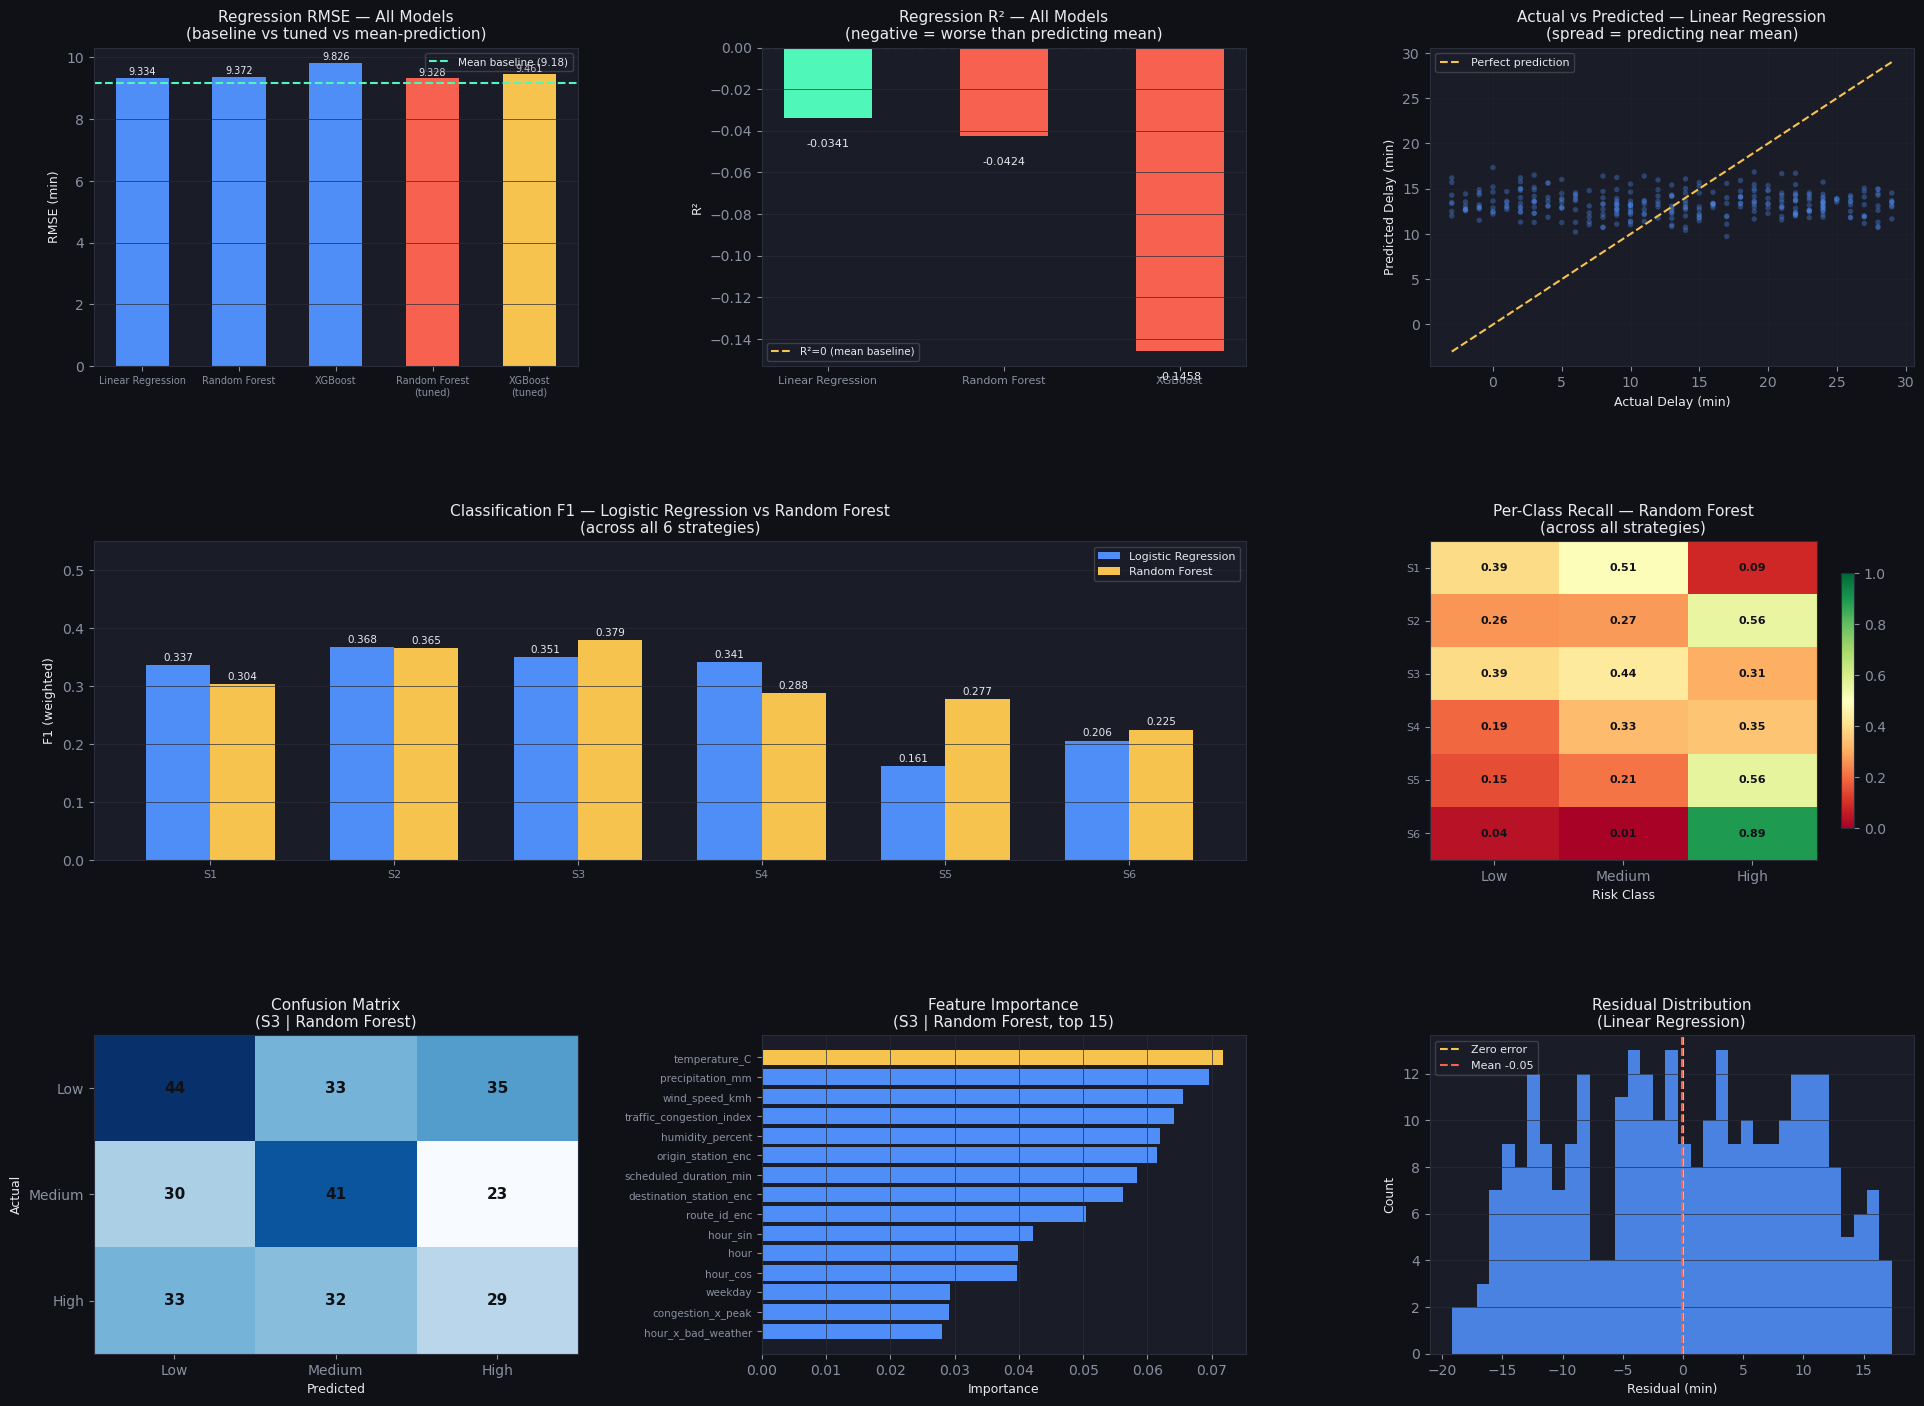

Exception ignored in: <function ResourceTracker.__del__ at 0x102ba2200>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1029ba200>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102aa6200>
Traceback (most recent call last

In [33]:
# =============================================================================
# 5.4  VISUALISATIONS - ML Modeling Full Experimentation Results
# =============================================================================
print("── 5.4 VISUALISATIONS ──")

DARK='#0f1117'; CARD='#1a1d27'; ACCENT='#4f8ef7'; ACCENT2='#f7c34f'
ACCENT3='#f7614f'; ACCENT4='#4ff7b8'; TEXT='#e8eaf0'; SUBTEXT='#8b90a0'
palette=[ACCENT, ACCENT2, ACCENT3, ACCENT4, '#b44ff7', '#f74fb4']
 
plt.rcParams.update({
    'figure.facecolor':DARK, 'axes.facecolor':CARD, 'axes.edgecolor':'#2a2d3a',
    'axes.labelcolor':TEXT, 'xtick.color':SUBTEXT, 'ytick.color':SUBTEXT,
    'text.color':TEXT, 'grid.color':'#2a2d3a', 'grid.linewidth':0.5,
    'font.family':'DejaVu Sans', 'axes.titlesize':11, 'axes.labelsize':9,
})
 
fig = plt.figure(figsize=(20, 20), facecolor=DARK)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38,
                       left=0.06, right=0.97, top=0.94, bottom=0.04)


# ── Plot 1 · Regression RMSE — all models + tuned vs baseline ────────────────
# Compares RMSE of all three regression models (baseline + tuned) against the mean-prediction baseline
ax1 = fig.add_subplot(gs[0, 0])

names_r = list(reg_results.keys())
rmses_r = [reg_results[n]['RMSE'] for n in names_r]

tuned_labels = [f'{n}\n(tuned)' for n in tuning_configs]
tuned_rmses = [tuned_reg_results[n]['RMSE'] for n in tuning_configs]

all_names = names_r + tuned_labels
all_rmses = rmses_r + tuned_rmses

colors_r = [ACCENT3 if v == min(all_rmses) else
            (ACCENT2 if '(tuned)' in n else ACCENT)
            for n, v in zip(all_names, all_rmses)]
bars1 = ax1.bar(all_names, all_rmses, color=colors_r, edgecolor='none', width=0.55)
ax1.axhline(baseline_rmse, color=ACCENT4, lw=1.5, ls='--',
            label=f'Mean baseline ({baseline_rmse:.2f})')
for bar, val in zip(bars1, all_rmses):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{val:.3f}', ha='center', va='bottom', color=TEXT, fontsize=7)
ax1.set_title('Regression RMSE — All Models\n(baseline vs tuned vs mean-prediction)')
ax1.set_ylabel('RMSE (min)'); ax1.grid(axis='y')
ax1.legend(fontsize=7.5, framealpha=0.2)
ax1.tick_params(axis='x', labelsize=7)
 

# ── Plot 2 · Regression R² — all models ──────────────────────────────────────
# Evaluate how much variance in arrival delay each regression model explains using R²
ax2 = fig.add_subplot(gs[0, 1])
r2s = [reg_results[n]['R²'] for n in reg_results]

colors_r2 = [ACCENT4 if v == max(r2s) else ACCENT3 for v in r2s]
bars2 = ax2.bar(list(reg_results.keys()), r2s, color=colors_r2, edgecolor='none', width=0.5)
ax2.axhline(0, color=ACCENT2, lw=1.5, ls='--', label='R²=0 (mean baseline)')
for bar, val in zip(bars2, r2s):
    ax2.text(bar.get_x()+bar.get_width()/2, val - 0.01,
             f'{val:.4f}', ha='center', va='top', color=TEXT, fontsize=8)
ax2.set_title('Regression R² — All Models\n(negative = worse than predicting mean)')
ax2.set_ylabel('R²'); ax2.grid(axis='y')
ax2.legend(fontsize=7.5, framealpha=0.2)
ax2.tick_params(axis='x', labelsize=8)
 

# ── Plot 3 · Actual vs predicted (best regression model) ─────────────────────
# Assess how closely the best regression model's predictions match actual delay values
ax3 = fig.add_subplot(gs[0, 2])
preds_best_reg = reg_results[best_reg_name]['preds']

ax3.scatter(y_reg_test, preds_best_reg, alpha=0.35, s=15,   # Points near the diagonal indicate accurate predictions
            color=ACCENT, edgecolors='none')
lims = [y_reg_test.min(), y_reg_test.max()]
ax3.plot(lims, lims, color=ACCENT2, lw=1.5, ls='--', label='Perfect prediction')
ax3.set_title(f'Actual vs Predicted — {best_reg_name}\n(spread = predicting near mean)')
ax3.set_xlabel('Actual Delay (min)'); ax3.set_ylabel('Predicted Delay (min)')
ax3.legend(fontsize=8, framealpha=0.2); ax3.grid(alpha=0.3)
 

# ── Plot 4 · F1 score — all 6 strategies × 2 classifiers ────────────────────
# Compare classification performance (weighted F1 score) across all risk-labeling strategies and classifiers
ax4 = fig.add_subplot(gs[1, :2])
strategy_names = list(dict.fromkeys(v['Strategy'] for v in clf_results.values()))
lr_f1s = [clf_results[k]['F1'] for k in clf_results if 'Logistic' in k]     # Logistic Regression
rf_f1s = [clf_results[k]['F1'] for k in clf_results if 'Random' in k]       # Random Forest

x4 = np.arange(len(strategy_names)); w4 = 0.35
b4a = ax4.bar(x4 - w4/2, lr_f1s, width=w4, color=ACCENT, edgecolor='none', label='Logistic Regression')
b4b = ax4.bar(x4 + w4/2, rf_f1s, width=w4, color=ACCENT2, edgecolor='none', label='Random Forest')
for bar, val in zip(list(b4a)+list(b4b), lr_f1s+rf_f1s):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
             f'{val:.3f}', ha='center', va='bottom', color=TEXT, fontsize=7.5)
ax4.set_title('Classification F1 — Logistic Regression vs Random Forest\n(across all 6 strategies)')
ax4.set_ylabel('F1 (weighted)'); ax4.set_xticks(x4)
short_strat = [s.split('(')[0].strip() for s in strategy_names]
ax4.set_xticklabels(short_strat, fontsize=8)
ax4.legend(fontsize=8, framealpha=0.2); ax4.grid(axis='y')
ax4.set_ylim(0, 0.55)
 

# ── Plot 5 · Per-class recall heatmap — best classifier per strategy ──────────
# Visualize class-level recall to determine how well each strategy identifies Low-, Medium-, and High-risk delays
ax5 = fig.add_subplot(gs[1, 2])
rf_keys = [k for k in clf_results if 'Random' in k]
recall_matrix = np.array([
    [clf_results[k]['Recall_Low'],
     clf_results[k]['Recall_Med'],
     clf_results[k]['Recall_High']]
    for k in rf_keys
])

im = ax5.imshow(recall_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax5.set_xticks([0,1,2]); ax5.set_xticklabels(risk_labels)
ax5.set_yticks(range(len(short_strat)))
ax5.set_yticklabels(short_strat, fontsize=8)
for i in range(len(rf_keys)):
    for j in range(3):
        ax5.text(j, i, f'{recall_matrix[i,j]:.2f}', ha='center', va='center',
                 color=DARK, fontsize=8, fontweight='bold')
plt.colorbar(im, ax=ax5, shrink=0.8)
ax5.set_title('Per-Class Recall — Random Forest\n(across all strategies)')
ax5.set_xlabel('Risk Class')
 

# ── Plot 6 · Confusion matrix — best overall ─────────────────────────────────
# Examine the distribution of classification errors and identify which risk categories are most frequently confused
ax6 = fig.add_subplot(gs[2, 0])
best_preds = clf_results[best_key]['preds']
best_y_test = clf_results[best_key]['y_test']
cm = confusion_matrix(best_y_test, best_preds)

ax6.imshow(cm, cmap='Blues', aspect='auto')
ax6.set_xticks([0,1,2]); ax6.set_yticks([0,1,2])
ax6.set_xticklabels(risk_labels); ax6.set_yticklabels(risk_labels)
for i in range(3):
    for j in range(3):
        ax6.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=11,
                 fontweight='bold',
                 color=TEXT if cm[i,j] < cm.max()/2 else DARK)
best_short = f"{best_info['Strategy'].split('(')[0].strip()} | {best_info['Classifier']}"
ax6.set_title(f'Confusion Matrix\n({best_short})')
ax6.set_xlabel('Predicted'); ax6.set_ylabel('Actual')
 

# ── Plot 7 · Feature importance — best classifier ────────────────────────────
# Identify the most influential features driving predictions
ax7 = fig.add_subplot(gs[2, 1])
best_clf_model = clf_results[best_key]['model']
if hasattr(best_clf_model, 'feature_importances_'):
    fi = pd.Series(best_clf_model.feature_importances_, index=FEATURE_COLS)
    top_fi = fi.sort_values(ascending=True).tail(15)
    colors_fi = [ACCENT2 if v == top_fi.max() else ACCENT for v in top_fi.values]
    ax7.barh(top_fi.index, top_fi.values, color=colors_fi, edgecolor='none')
    ax7.set_title(f'Feature Importance\n({best_short}, top 15)')
    ax7.set_xlabel('Importance'); ax7.grid(axis='x')
    ax7.tick_params(axis='y', labelsize=7.5)
 
# ── Plot 8 · Residual distribution — best regression model ───────────────────
# Analyze prediction errors (residuals) to assess model bias and overall regression fit quality
ax8 = fig.add_subplot(gs[2, 2])
residuals = y_reg_test.values - preds_best_reg      # Residual = actual delay - predicted delay

ax8.hist(residuals, bins=35, color=ACCENT, edgecolor='none', alpha=0.9)
ax8.axvline(0, color=ACCENT2, lw=1.5, ls='--', label='Zero error')
ax8.axvline(residuals.mean(), color=ACCENT3, lw=1.5, ls='--',
            label=f'Mean {residuals.mean():.2f}')
ax8.set_title(f'Residual Distribution\n({best_reg_name})')
ax8.set_xlabel('Residual (min)'); ax8.set_ylabel('Count')
ax8.legend(fontsize=8, framealpha=0.2); ax8.grid(axis='y')
 
 
plt.tight_layout()
plt.show()

**KEY TAKEAWAYS**

*Regression*
- All three models (Linear Regression, Random Forest, XGBoost) produced negative R², meaning none of them explain delay variance better than simply predicting the mean delay for every trip. This reflects a fundamental dataset characteristic where delay values are spread nearly uniformly across all feature combinations.
- Predicted values cluster in a horizontal band around 10–15 min regardless of actual delay, showing the model defaults to the mean rather than learning the true relationship.
- Linear Regression achieved the lowest RMSE (9.334 min), outperforming both Random Forest and XGBoost. This is consistent with the Section 3 finding that features have weak linear correlations with delay — when there is no non-linear signal to exploit, a simple model holds up as well as or better than complex ensembles.
- Hyperparameter tuning yielded only marginal improvement (RMSE 9.372 → 9.328 for Random Forest).

*Classification*
- Reframing the problem as risk classification (Low / Medium / High) proved more tractable than exact delay prediction, with the best strategy achieving F1=0.379 and Accuracy=0.380.
- The best overall result was **S3: Fixed bins + SMOTE + Random Forest** (F1=0.379). SMOTE on fixed bins helped by balancing the High-risk class, which was severely underrepresented in the original distribution and had recall as low as 0.09 without any correction.
- Having class_weight {0:1, 1:1, 2:2} is a deliberate tradeoff, not a general improvement. It pushes High-risk recall to ~0.90 but collapses Low and Medium recall to near zero. This variant is only appropriate if the sole objective is flagging high-risk trips (e.g. a safety alert system), not balanced prediction.
- Logistic Regression performed competitively against Random Forest across most strategies, further supporting the conclusion that the dataset does not contain enough non-linear structure for ensemble models to gain a meaningful advantage.

*Overall*
- The weak predictive performance across both tasks is consistent and explainable —
  it is not due to poor feature engineering or model selection, but rather because
  delays in this dataset appear largely random with respect to the available features.
- SHAP will be used in the next section to address the problem of "delays appear largely random with respect to the available features". Even when overall accuracy is modest, explainability analysis can reveal which features the model does rely on and provide interpretable insights for each individual prediction.

<h4>SECTION 6: MODEL EXPLAINABILITY - SHAP</h4>

In [37]:
# ── 6.1  Rebuild Data & Models ──────────────────────────────────────────────────────
print("=" * 60)
print("SECTION 6 · MODEL EXPLAINABILITY — SHAP")
print("=" * 60)

df = pd.read_csv('transport_features.csv')
 
DROP_COLS = [
    'trip_id', 'date', 'time', 'scheduled_departure', 'scheduled_arrival',
    'weather_condition', 'event_type', 'event_label', 'season',
    'transport_type', 'route_id', 'origin_station', 'destination_station',
]
TARGET_REG = 'actual_arrival_delay_min'
TARGET_CLF = 'delayed'
 
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS +
                [TARGET_REG, 'actual_departure_delay_min', TARGET_CLF]]

# Separate predictors from regression and classification targets
X = df[FEATURE_COLS]
y_reg = df[TARGET_REG]
y_clf = df[TARGET_CLF]
 
X_train, X_temp, y_reg_train, y_reg_temp, y_clf_train, y_clf_temp = train_test_split(
    X, y_reg, y_clf, test_size=0.30, random_state=42, stratify=y_clf)

X_val, X_test, y_reg_val, y_reg_test, y_clf_val, y_clf_test = train_test_split(
    X_temp, y_reg_temp, y_clf_temp, test_size=0.50, random_state=42, stratify=y_clf_temp)

# Risk labels — fixed bins (S3 is the best strategy from Section 4)
def assign_risk_fixed(d):
    return 0 if d < 10 else (1 if d < 20 else 2)
 
y_risk_train_fixed = y_reg_train.apply(assign_risk_fixed)
y_risk_test_fixed  = y_reg_test.apply(assign_risk_fixed)
risk_labels = ['Low', 'Medium', 'High']
 
# SMOTE on training set
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_risk_train_fixed)
 
# Best models from Section 4
lr_reg = LinearRegression().fit(X_train, y_reg_train)
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_split=5,
    random_state=42, n_jobs=-1).fit(X_sm, y_sm)
 
print(f"  Regression  : Linear Regression  (best Section 4 regression model)")
print(f"  Classifier  : Random Forest S3   (best Section 4 classification strategy)")
print(f"  Test set    : {len(X_test)} rows\n")

SECTION 6 · MODEL EXPLAINABILITY — SHAP
  Regression  : Linear Regression  (best Section 4 regression model)
  Classifier  : Random Forest S3   (best Section 4 classification strategy)
  Test set    : 300 rows



In [38]:
# ── 6.2  SHAP Explainers ──────────────────────────────────────────────────────
# SHAP quantifies how much each feature contributes to a prediction
print("── 6.2 Compute SHAP values ──")

explainer_reg = shap.LinearExplainer(lr_reg, X_train)       # LinearExplainer provides exact SHAP values for linear regression models
shap_vals_reg = explainer_reg.shap_values(X_test)           # Calculate SHAP values for all test observations
expected_reg = explainer_reg.expected_value                 # Expected value = average prediction before considering feature effects
print(f"  Regression  : SHAP values computed — shape {shap_vals_reg.shape}")
 
explainer_clf = shap.TreeExplainer(rf_clf)                  # TreeExplainer efficiently computes SHAP values for tree-based models
shap_vals_clf = explainer_clf.shap_values(X_test)           # Calculate SHAP values for all test observations and classes
expected_clf = explainer_clf.expected_value
shap_vals_clf = np.array(shap_vals_clf)                     # shape: (n_samples, n_features, n_classes)

print(f"  Classifier : SHAP values computed — shape {shap_vals_clf.shape}\n")
print(f"  Base value : Reg={expected_reg:.3f} min | "
      f"Clf={[f'{v:.3f}' for v in expected_clf]}")

── 6.2 Compute SHAP values ──
  Regression  : SHAP values computed — shape (300, 38)
  Classifier : SHAP values computed — shape (300, 38, 3)

  Base value : Reg=13.130 min | Clf=['0.334', '0.333', '0.333']


In [40]:
# ── 6.3  Global Explanations — Regression ────────────────────────────────────────
print("── 6.3 Global Explanations — Regression ──")
 
# Average absolute contribution of each feature across all test trips
mean_abs_shap_reg = pd.Series(
    np.abs(shap_vals_reg).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)
 
print("  Top 10 features by mean |SHAP| (regression):")
for feat, val in mean_abs_shap_reg.head(10).items():
    print(f"    {feat:20s}: {val:.4f} min")

── 6.3 Global Explanations — Regression ──
  Top 10 features by mean |SHAP| (regression):
    time_of_day         : 0.8904 min
    season_Summer       : 0.7549 min
    hour_sin            : 0.7095 min
    has_event           : 0.6965 min
    event_severity      : 0.3988 min
    origin_station_enc  : 0.3853 min
    hour                : 0.3703 min
    humidity_percent    : 0.3623 min
    hour_cos            : 0.3273 min
    season_Winter       : 0.3241 min


In [41]:
# ── 6.4  Global Explanations — Classification (High-risk class) ───────────────────
print("── 6.4 Global Explanations — Classification ──")
 
# Focus on class 2 (High risk) — most critical for transit planning
shap_high = shap_vals_clf[:, :, 2] 

# Compute average feature importance for High-risk classification.
mean_abs_shap_clf = pd.Series(
    np.abs(shap_high).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)
 
print("  Top 10 features by mean |SHAP| (High-risk class):")
for feat, val in mean_abs_shap_clf.head(10).items():
    print(f"    {feat:20s}: {val:.4f}")

── 6.4 Global Explanations — Classification ──
  Top 10 features by mean |SHAP| (High-risk class):
    humidity_percent    : 0.0163
    transport_type_enc  : 0.0122
    has_event           : 0.0120
    temperature_C       : 0.0115
    precipitation_mm    : 0.0101
    hour_cos            : 0.0086
    hour_sin            : 0.0086
    wind_speed_kmh      : 0.0078
    origin_station_enc  : 0.0073
    is_bad_weather      : 0.0069


In [43]:
# ── 6.5  GLocal Explanations — Individual Trips ───────────────────────────────────
# Explain individual predictions rather than overall model behaviour
print("── 6.5  GLocal Explanations — Individual Trips ──")
 
# Select representative high-delay and low-delay trips for interpretation
y_reg_test_arr = y_reg_test.values                  # Retrieve actual delay values from the test set
high_delay_idx = np.argsort(y_reg_test_arr)[-5]     # Choose a severe delay example
low_delay_idx = np.argsort(y_reg_test_arr)[5]       # Choose a low-delay example
 
for label, idx in [('High-delay trip', high_delay_idx),
                   ('Low-delay trip', low_delay_idx)]:
    actual = y_reg_test_arr[idx]
    predicted = lr_reg.predict(X_test.iloc[[idx]])[0]
    sv_series = pd.Series(shap_vals_reg[idx].astype(float), index=FEATURE_COLS)

    top_pos = sv_series.nlargest(3)     # Features that increased the predicted delay the most
    top_neg = sv_series.nsmallest(3)    # Features that reduced the predicted delay the most
    
    print(f"\n  {label}:")
    print(f"    Actual={actual:.1f} min | Predicted={predicted:.1f} min | "
          f"Base={expected_reg:.1f} min")
    print(f"    Top delay drivers (+):")
    for f, v in top_pos.items():
        print(f"      {f:25s}: +{v:.3f} min")
    print(f"    Top delay reducers (-):")
    for f, v in top_neg.items():
        print(f"      {f:25s}: {v:.3f} min")

── 6.5  GLocal Explanations — Individual Trips ──

  High-delay trip:
    Actual=29.0 min | Predicted=13.5 min | Base=13.1 min
    Top delay drivers (+):
      hour_sin                 : +1.107 min
      congestion_x_peak        : +1.049 min
      has_event                : +0.579 min
    Top delay reducers (-):
      season_Summer            : -1.329 min
      origin_station_enc       : -0.714 min
      is_evening_rush          : -0.625 min

  Low-delay trip:
    Actual=-3.0 min | Predicted=14.3 min | Base=13.1 min
    Top delay drivers (+):
      weather_Snow             : +0.737 min
      has_event                : +0.579 min
      season_Summer            : +0.543 min
    Top delay reducers (-):
      humidity_percent         : -0.608 min
      time_of_day              : -0.554 min
      event_severity           : -0.315 min


── 6.6 Generate SHAP plots ──


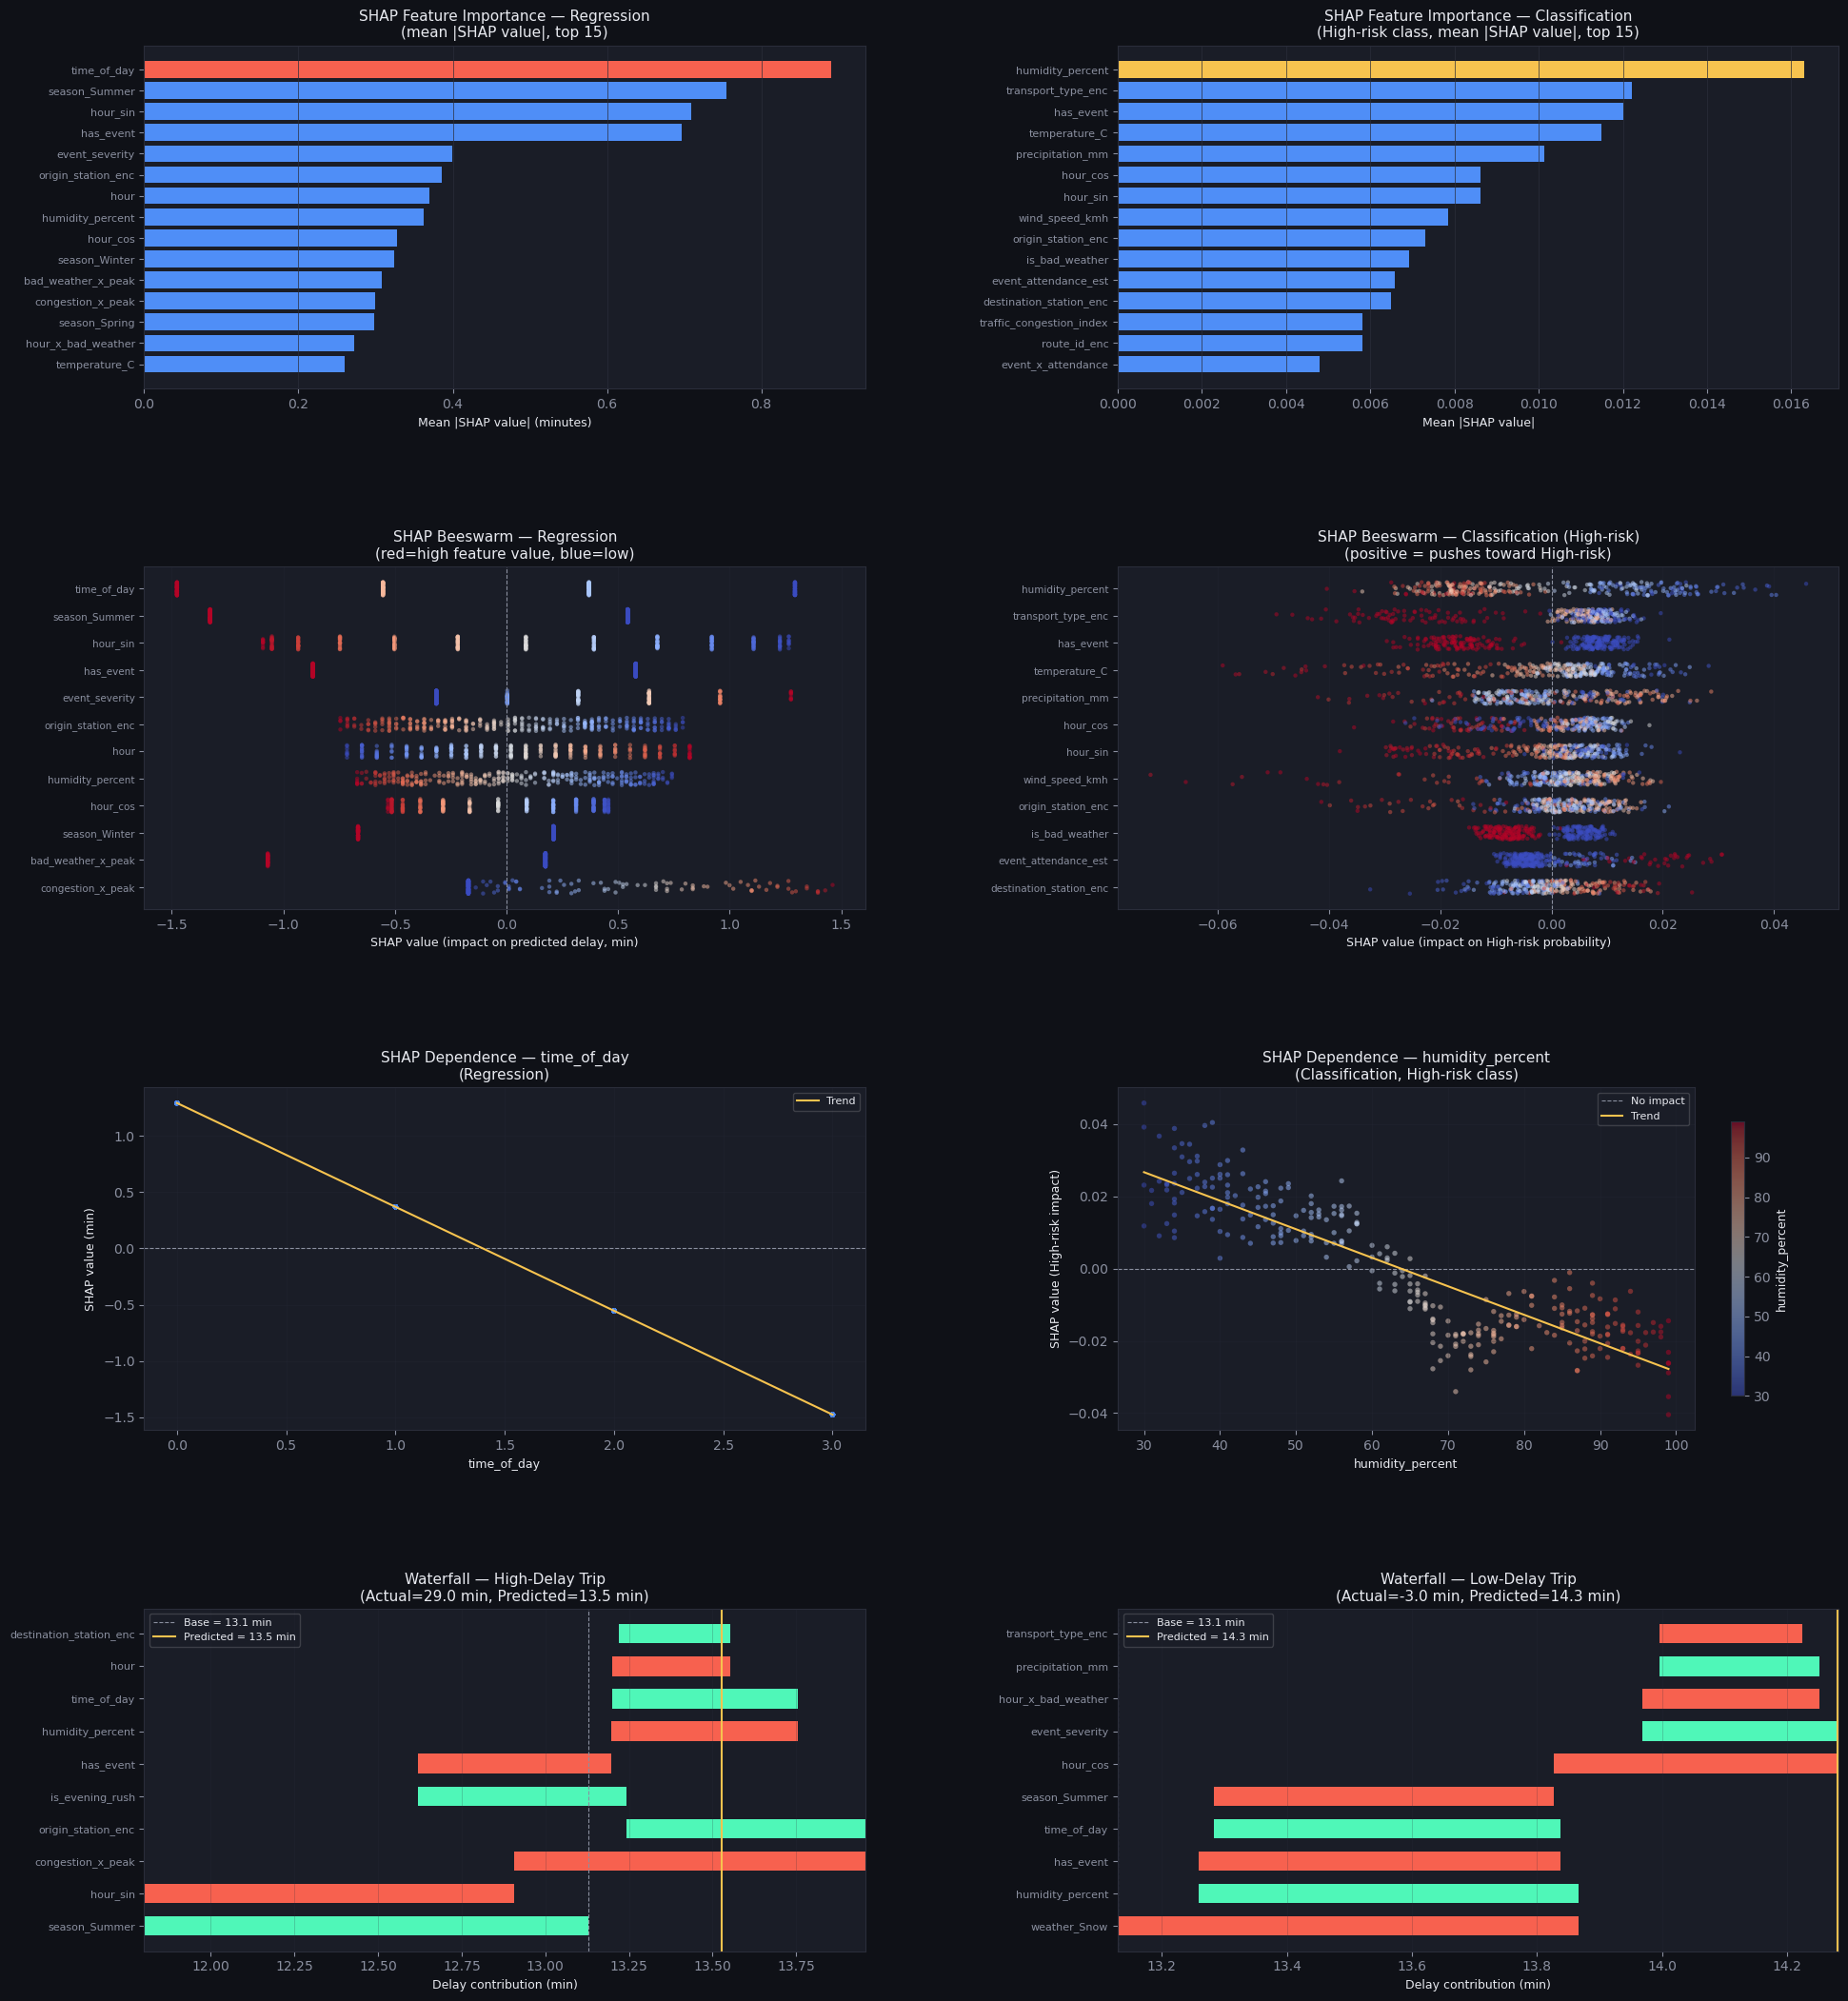

In [44]:
# ── 6.6  Visualizations ────────────────────────────────────────────────────────────
print("── 6.6 Generate SHAP plots ──")
 
DARK='#0f1117'; CARD='#1a1d27'; ACCENT='#4f8ef7'; ACCENT2='#f7c34f'
ACCENT3='#f7614f'; ACCENT4='#4ff7b8'; TEXT='#e8eaf0'; SUBTEXT='#8b90a0'
 
plt.rcParams.update({
    'figure.facecolor':DARK, 'axes.facecolor':CARD, 'axes.edgecolor':'#2a2d3a',
    'axes.labelcolor':TEXT, 'xtick.color':SUBTEXT, 'ytick.color':SUBTEXT,
    'text.color':TEXT, 'grid.color':'#2a2d3a', 'grid.linewidth':0.5,
    'font.family':'DejaVu Sans', 'axes.titlesize':11, 'axes.labelsize':9,
})
 
fig = plt.figure(figsize=(20, 22), facecolor=DARK)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.52, wspace=0.35,
                       left=0.08, right=0.97, top=0.95, bottom=0.04)

 
# ── Plot 1 · SHAP feature importance — regression ────────────────────────────
# Rank features by their overall contribution to arrival-delay predictions across all test trips
ax1 = fig.add_subplot(gs[0, 0])
top15_reg = mean_abs_shap_reg.head(15).sort_values()

colors_r = [ACCENT3 if v == top15_reg.max() else ACCENT for v in top15_reg.values]
ax1.barh(top15_reg.index, top15_reg.values, color=colors_r, edgecolor='none')
ax1.set_title('SHAP Feature Importance — Regression\n(mean |SHAP value|, top 15)')
ax1.set_xlabel('Mean |SHAP value| (minutes)')
ax1.grid(axis='x'); ax1.tick_params(axis='y', labelsize=8)
 

# ── Plot 2 · SHAP feature importance — classification (High-risk) ─────────────
# Rank features by their overall contribution to High-risk delay classifications
ax2 = fig.add_subplot(gs[0, 1])
top15_clf = mean_abs_shap_clf.head(15).sort_values()

colors_c = [ACCENT2 if v == top15_clf.max() else ACCENT for v in top15_clf.values]
ax2.barh(top15_clf.index, top15_clf.values, color=colors_c, edgecolor='none')
ax2.set_title('SHAP Feature Importance — Classification\n(High-risk class, mean |SHAP value|, top 15)')
ax2.set_xlabel('Mean |SHAP value|')
ax2.grid(axis='x'); ax2.tick_params(axis='y', labelsize=8)
 

# ── Plot 3 · SHAP beeswarm — regression ──────────────────────────────────────
# Visualize how individual feature values increase or decrease predicted arrival delays across all trips
#   Each dot is one test sample
#   Position shows SHAP impact on predicted delay
#   Colour shows the feature's raw value (red=high, blue=low)
ax3 = fig.add_subplot(gs[1, 0])
top_feat_reg = mean_abs_shap_reg.head(12).index.tolist()        # Select the 12 most important features based on global SHAP importance
feat_idx_reg = [FEATURE_COLS.index(f) for f in top_feat_reg]
shap_subset = shap_vals_reg[:, feat_idx_reg]                    # Keep only SHAP values for the selected features
X_test_sub = X_test[top_feat_reg].values                        # Extract corresponding feature values from the test set
 
for i, feat in enumerate(reversed(top_feat_reg)):
    fi = top_feat_reg.index(feat)
    vals = shap_subset[:, fi]
    raw = X_test_sub[:, fi].astype(float)
    norm = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    jitter = np.random.RandomState(42).uniform(-0.25, 0.25, len(vals))
    ax3.scatter(vals, np.full_like(vals, i) + jitter,
                c=norm, cmap='coolwarm', alpha=0.5, s=10, linewidths=0)
ax3.set_yticks(range(len(top_feat_reg)))
ax3.set_yticklabels(list(reversed(top_feat_reg)), fontsize=7.5)
ax3.axvline(0, color=SUBTEXT, lw=0.8, ls='--')
ax3.set_title('SHAP Beeswarm — Regression\n(red=high feature value, blue=low)')
ax3.set_xlabel('SHAP value (impact on predicted delay, min)')
ax3.grid(axis='x', alpha=0.3)
 
# ── Plot 4 · SHAP beeswarm — classification (High-risk) ──────────────────────
# Visualize how individual feature values influence the probability of a trip being classified as High Risk
#   Positive SHAP = pushes toward High-risk
#   Negative SHAP = pushes away from High-risk
ax4 = fig.add_subplot(gs[1, 1])
top_feat_clf = mean_abs_shap_clf.head(12).index.tolist()
feat_idx_clf = [FEATURE_COLS.index(f) for f in top_feat_clf]
shap_sub_clf = shap_high[:, feat_idx_clf]
X_test_clf = X_test[top_feat_clf].values
 
for i, feat in enumerate(reversed(top_feat_clf)):
    fi = top_feat_clf.index(feat)
    vals = shap_sub_clf[:, fi]
    raw = X_test_clf[:, fi].astype(float)
    norm = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    jitter = np.random.RandomState(42).uniform(-0.25, 0.25, len(vals))
    ax4.scatter(vals, np.full_like(vals, i) + jitter,
                c=norm, cmap='coolwarm', alpha=0.5, s=10, linewidths=0)
ax4.set_yticks(range(len(top_feat_clf)))
ax4.set_yticklabels(list(reversed(top_feat_clf)), fontsize=7.5)
ax4.axvline(0, color=SUBTEXT, lw=0.8, ls='--')
ax4.set_title('SHAP Beeswarm — Classification (High-risk)\n(positive = pushes toward High-risk)')
ax4.set_xlabel('SHAP value (impact on High-risk probability)')
ax4.grid(axis='x', alpha=0.3)
 
# ── Plot 5 · SHAP dependence — top regression feature ────────────────────────
# Examine how the most important regression feature affects predicted delay magnitude and direction
#   Slope reveals whether the relationship is linear, threshold-based, or noisy
ax5 = fig.add_subplot(gs[2, 0])                
top1_reg = mean_abs_shap_reg.index[0]           # Identify the most important feature from the regression SHAP analysis
fi1 = FEATURE_COLS.index(top1_reg)
x_dep = X_test[top1_reg].values.astype(float)   # Extract raw feature values from the test set
s_dep = shap_vals_reg[:, fi1].astype(float)     # Extract SHAP contributions corresponding to the selected feature

ax5.scatter(x_dep, s_dep, alpha=0.5, s=15, color=ACCENT, edgecolors='none')
ax5.axhline(0, color=SUBTEXT, lw=0.8, ls='--')
z = np.polyfit(x_dep, s_dep, 1)
xline = np.linspace(x_dep.min(), x_dep.max(), 100)
ax5.plot(xline, np.polyval(z, xline), color=ACCENT2, lw=1.5, label='Trend')
ax5.set_title(f'SHAP Dependence — {top1_reg}\n(Regression)')
ax5.set_xlabel(top1_reg); ax5.set_ylabel('SHAP value (min)')
ax5.legend(fontsize=8, framealpha=0.2); ax5.grid(alpha=0.3)
 
# ── Plot 6 · SHAP dependence — top classification feature ────────────────────
# Examine how the most important classification feature influences High-risk delay predictions
ax6 = fig.add_subplot(gs[2, 1])
top1_clf = mean_abs_shap_clf.index[0]
fi2 = FEATURE_COLS.index(top1_clf)
x_dep2 = X_test[top1_clf].values.astype(float)
s_dep2 = shap_high[:, fi2].astype(float)

sc = ax6.scatter(x_dep2, s_dep2, alpha=0.5, s=15,
                 c=x_dep2, cmap='coolwarm', edgecolors='none')
ax6.axhline(0, color=SUBTEXT, lw=0.8, ls='--', label='No impact')
z2 = np.polyfit(x_dep2, s_dep2, 1)
xline2 = np.linspace(x_dep2.min(), x_dep2.max(), 100)
ax6.plot(xline2, np.polyval(z2, xline2), color=ACCENT2, lw=1.5, label='Trend')
plt.colorbar(sc, ax=ax6, shrink=0.8, label=top1_clf)
ax6.set_title(f'SHAP Dependence — {top1_clf}\n(Classification, High-risk class)')
ax6.set_xlabel(top1_clf); ax6.set_ylabel('SHAP value (High-risk impact)')
ax6.legend(fontsize=8, framealpha=0.2); ax6.grid(alpha=0.3)
 
# ── Plot 7 · Waterfall — high-delay trip ─────────────────────────────────────
# Explain a single high-delay trip by showing how each feature moves the model from the baseline delay estimate to the final predicted delay
ax7 = fig.add_subplot(gs[3, 0])
idx = high_delay_idx
sv = shap_vals_reg[idx]
feat_sv = pd.Series(sv.astype(float), index=FEATURE_COLS).reindex(
    pd.Series(np.abs(sv).astype(float), index=FEATURE_COLS).nlargest(10).index)

# Start from the model's baseline prediction (average delay)
cumulative = expected_reg

# Compute cumulative positions so each feature contribution builds on the previous prediction step
positions = []
for val in feat_sv.values:
    positions.append(cumulative)
    cumulative += val
    
colors_wf = [ACCENT3 if v > 0 else ACCENT4 for v in feat_sv.values]
bars7 = ax7.barh(range(len(feat_sv)), feat_sv.values,
                 left=positions, color=colors_wf, edgecolor='none', height=0.6)
ax7.axvline(expected_reg, color=SUBTEXT, lw=0.8, ls='--',
            label=f'Base = {expected_reg:.1f} min')
ax7.axvline(lr_reg.predict(X_test.iloc[[idx]])[0],
            color=ACCENT2, lw=1.5, ls='-',
            label=f'Predicted = {lr_reg.predict(X_test.iloc[[idx]])[0]:.1f} min')
ax7.set_yticks(range(len(feat_sv)))
ax7.set_yticklabels(feat_sv.index, fontsize=8)
ax7.set_title(f'Waterfall — High-Delay Trip\n'
              f'(Actual={y_reg_test_arr[idx]:.1f} min, '
              f'Predicted={lr_reg.predict(X_test.iloc[[idx]])[0]:.1f} min)')
ax7.set_xlabel('Delay contribution (min)')
ax7.legend(fontsize=8, framealpha=0.2); ax7.grid(axis='x', alpha=0.3)
 
# ── Plot 8 · Waterfall — low-delay trip ───────────────────────────────────────
# Explain a single low-delay trip by identifying the features that reduced the predicted delay
ax8 = fig.add_subplot(gs[3, 1])
idx2 = low_delay_idx
sv2 = shap_vals_reg[idx2]
feat_sv2 = pd.Series(sv2.astype(float), index=FEATURE_COLS).reindex(
    pd.Series(np.abs(sv2).astype(float), index=FEATURE_COLS).nlargest(10).index)
cumulative2 = expected_reg
positions2 = []
for val in feat_sv2.values:
    positions2.append(cumulative2)
    cumulative2 += val
colors_wf2 = [ACCENT3 if v > 0 else ACCENT4 for v in feat_sv2.values]
ax8.barh(range(len(feat_sv2)), feat_sv2.values,
         left=positions2, color=colors_wf2, edgecolor='none', height=0.6)
ax8.axvline(expected_reg, color=SUBTEXT, lw=0.8, ls='--',
            label=f'Base = {expected_reg:.1f} min')
ax8.axvline(lr_reg.predict(X_test.iloc[[idx2]])[0],
            color=ACCENT2, lw=1.5, ls='-',
            label=f'Predicted = {lr_reg.predict(X_test.iloc[[idx2]])[0]:.1f} min')
ax8.set_yticks(range(len(feat_sv2)))
ax8.set_yticklabels(feat_sv2.index, fontsize=8)
ax8.set_title(f'Waterfall — Low-Delay Trip\n'
              f'(Actual={y_reg_test_arr[idx2]:.1f} min, '
              f'Predicted={lr_reg.predict(X_test.iloc[[idx2]])[0]:.1f} min)')
ax8.set_xlabel('Delay contribution (min)')
ax8.legend(fontsize=8, framealpha=0.2); ax8.grid(axis='x', alpha=0.3)
 
plt.tight_layout()
plt.show()

**KEY TAKEAWAYS**

*Global Explanations (Regression)*
- `time_of_day`, `season_Summer`, and `hour_sin` are the top three features by mean |SHAP| value, confirming that time and seasonal structure are the primary drivers of delay predictions in the regression model (not weather or event features as initially hypothesised).
- All SHAP contributions remain small (below ±1.5 min), meaning no single feature pushes predictions far from the base value of 13.1 min. This visually explains why the model defaults to predicting near the mean for almost every trip.
- Weather features (temperature, precipitation, wind) rank low in regression SHAP importance, consistent with the EDA finding that weather conditions differ by less than 1 min in average delay across all conditions.

*Global Explanations (Classification — High-risk)*
- `humidity_percent`, `transport_type_enc`, and `has_event` are the strongest predictors of High-risk classification, which is a different set of features from regression, suggesting the two tasks rely on different aspects of the data.
- Weather and event features are more prominent in classification than in regression, indicating the classifier picks up on contextual risk signals even when those features cannot predict exact delay magnitude.
- The negative SHAP dependence of `humidity_percent` on High-risk probability is counterintuitive: higher humidity is associated with lower High-risk SHAP values in this dataset. This likely reflects a spurious pattern learned from limited data rather than a real relationship, and is acknowledged as a limitation.

*Local Explanations (Individual Trips)*
- For the highest-delay trip (actual = 29 min), the model predicted only 13.5 min. SHAP shows `hour_sin` (+1.1 min) and `congestion_x_peak` (+1.0 min) as the top drivers, but their combined contribution is only +0.4 min above base. This implies that the model structurally cannot reach extreme delay values because no feature carries enough weight to push predictions that far.
- For the lowest-delay trip (actual = -3 min), the model predicted 14.3 min, which was even further from the actual than the high-delay case. SHAP shows `weather_Snow` and `has_event` pushing the prediction upward, with nothing pulling it low enough, confirming the model has no mechanism to predict very early or on-time arrivals.
- The contrast between the two waterfall plots illustrates the core limitation clearly: SHAP contributions are small and symmetric regardless of how extreme
  the actual delay is, which is the individual-trip equivalent of the horizontal band seen in the actual vs predicted scatter plot.

*Overall*
- SHAP confirms that the weak aggregate performance seen in Section 5 is not due to any single feature being wrong or missing. The model distributes attention across many features, each contributing marginally, with no dominant signal.
- Despite modest predictive accuracy, SHAP provides genuine interpretability value: it identifies which features the model relies on (time, season, events) and provides a per-trip explanation that could be surfaced to users in a real system.
- In a production forecasting system, these findings would motivate collecting richer data sources such as real-time vehicle tracking, passenger load, and infrastructure incident logs, which are known to be stronger predictors of transit delay than the weather and calendar features available in this dataset.

##### Hypothesis Evaluation

- H1: Rejected. SHAP analysis showed weather features rank low in regression importance. Time and seasonal features were stronger predictors.

- H2: Partially supported. Peak hour interaction features appeared in SHAP but with small contributions. The combination did not compound meaningfully.

- H3: Partially supported. `has_event` and `event_severity` appear consistently in SHAP top features, but absolute contributions remain below 0.7 min.

- H4: Partially rejected. Classification achieved F1=0.379 (modest but above random). Regression failed to beat the mean-prediction baseline, suggesting the available features are insufficient for exact delay prediction.